In [2]:
# import libraries
import pandas as pd
import seaborn as sns

import matplotlib 
import matplotlib.pyplot as plt
plt.style.use('default') # 'ggplot'
from matplotlib.pyplot import figure

matplotlib.rcParams['figure.figsize'] = (12,8) # adjusts the config of the plots 


In [3]:
pd.set_option('display.max_rows', None)

In [4]:
myData = pd.read_pickle('joinedData.pkl')
myData.head()

,index,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,...,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted
0,0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,...,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0
1,0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,...,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1
2,1,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,...,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0
3,2,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,...,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1
4,3,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,...,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0


# Analysis

### Create bins for credit score ranges and DTI ranges

In [6]:
# bin ranges from experian [https://www.experian.com/blogs/ask-experian/infographic-what-are-the-different-scoring-ranges/]
#myData['cred_score_bin'] = pd.cut(myData.credit_score, bins = [0, 579, 669, 739, 799, 850], labels = ['poor (0-579)', 'fair (580-669)', 'good (670-739)', 'very good (740-799)', 'exceptional (800+)'])

# bin ranges per instructions
myData['cred_score_bin'] = pd.cut(myData.credit_score, bins = [520, 599, 649, 699, 749, 851], 
                                  labels = ['520-599', '600-649', '650-699', '700-749', '750+'],
                                 right = False)
myData.cred_score_bin.value_counts()

cred_score_bin
750+       233
520-599    115
600-649     92
700-749     84
650-699     77
Name: count, dtype: int64

In [7]:
# original -- too many categories
# bin ranges from investopedia [https://www.investopedia.com/terms/d/dti.asp]
# myData['dti_bin'] = pd.cut(myData.dti_ratio, bins = [0, 25, 35, 45, 50, 75, 100, 150, 200], 
#                           labels = ['0-25%', '26-35%', '36-45%', '46-50%', '51-75%', '76-100%', '100-150%', '151-200%'])

myData['dti_bin'] = pd.cut(myData.dti_ratio, bins = [0, 25, 35, 45, 50, 200], 
                           labels = ['0-25%', '26-35%', '36-45%', '46-50%', '>51%'],
                          right = False)
myData.dti_bin.value_counts()

dti_bin
>51%      271
26-35%    102
36-45%     91
0-25%      78
46-50%     59
Name: count, dtype: int64

In [8]:
# bins include 2 yr cutoff (instead of 1 yr) because of question related to 2 yrs
# note -- bin includes left, not right
myData['yrs_emp_bin'] = pd.cut(myData['years_employed'], bins = [0, 2, 5, 10, 40], 
                               labels = ['<2 yr', '2-5 yrs', '6-10 yrs', '10+ yrs'], right = False)
myData.yrs_emp_bin.value_counts()

yrs_emp_bin
10+ yrs     277
6-10 yrs    126
2-5 yrs     114
<2 yr        84
Name: count, dtype: int64

In [9]:
#261+110+96+95 = 562
277+126+114+84
#600 - 562 # 38 entries not in a bin


601

In [10]:
# create bins for interest rates (left side included per bin)
myData['int_rate_bin'] = pd.cut(myData['interest_rate'], bins = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
                               labels = ['5%', '6%', '7%', '8%', '9%', '10%', '11%', '12%', '13%', 
                                         '14%', '15%', '16%'],
                               right = False)
myData.int_rate_bin.value_counts()

int_rate_bin
10%    109
9%      84
11%     81
12%     74
8%      72
7%      49
13%     46
14%     41
6%      30
15%     13
5%       2
16%      0
Name: count, dtype: int64

In [11]:
# function to define ages
def age_bin(row):
    if (row.age >= 20 and row.age < 30) :
        return '20s'
    elif (row.age >= 30 and row.age < 40) :
        return '30s'
    elif (row.age >= 40 and row.age < 50) :
        return '40s'
    elif (row.age >= 50 and row.age < 60) :
        return '50s'
    elif (row.age >= 60 and row.age < 70) :
        return '60s'
    else :
        return '70+'
                                           

In [12]:
# use function to create age groups
myData['age_bin'] = myData.apply(age_bin, axis = 1)
myData[['age', 'age_bin']].head() # check values for accuracy

,age,age_bin
0,62,60s
1,62,60s
2,24,20s
3,50,50s
4,43,40s


In [13]:
# save data set
myData.to_pickle('binnedPickle.pkl')
myData = pd.read_pickle('binnedPickle.pkl')

### Assess multi loan borrower data

In [141]:
# add column assigning loan number by borrower
myData['loan_number'] = (myData.groupby('borrower_id').cumcount() + 1)

In [142]:
# Add column to estimate loan end date
myData['loan_end_date'] = myData.apply(lambda x: x['application_date'] 
                                       + pd.DateOffset(months = int(x['term_months'])), axis = 1)

In [148]:
# Create columns to get previous loan end date and compare to next loan start

# Sort loans chronologically within each borrower
myData = myData.sort_values(['borrower_id', 'application_date']).reset_index(drop=True)

# get next loan date for each borrower -- if looking at first loan 
# myData['next_application_date'] = (myData.groupby('borrower_id')['application_date'].shift(-1))

# Previous loan's payoff date (look at second loans)
myData['previous_loan_end_date'] = (myData.groupby('borrower_id')['loan_end_date'].shift(1))

# Was this loan taken out before the previous one ended?
myData['opened_before_previous_paid_off'] = (myData['application_date'] < myData['previous_loan_end_date'])

In [149]:
myData.head()


,index,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,...,days_delinquent,defaulted,cred_score_bin,dti_bin,yrs_emp_bin,int_rate_bin,loan_number,loan_end_date,previous_loan_end_date,opened_before_previous_paid_off
0,0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,...,0,0,520-599,>51%,6-10 yrs,13%,1,2027-01-08,NaT,False
1,0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,...,138,1,520-599,36-45%,6-10 yrs,14%,2,2028-08-13,2027-01-08,True
2,1,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,...,0,0,520-599,>51%,2-5 yrs,12%,1,2028-06-28,NaT,False
3,2,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,...,34,1,600-649,>51%,10+ yrs,11%,1,2029-05-18,NaT,False
4,3,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,...,0,0,700-749,36-45%,10+ yrs,9%,1,2028-03-24,NaT,False


In [218]:
# how many borrowers have more than one loan?
myData.query('loan_number >= 2')['borrower_id'].count()
# Of the 500 borrowers, 101 have more than one loan with the bank

np.int64(101)

In [219]:
# count of loans by borrower
myData.pivot_table(index = 'loan_number', columns = 'defaulted', values = 'loan_id', aggfunc = 'count')

defaulted,0,1
loan_number,,
1,377,123
2,78,23


In [158]:
# 123 / (377+123) #first loan default rate = 24.6%
23 / (78+23)      #second loan default rate = 22.8%
# there's not a big difference in default rate depending on how many loans a borrower has taken out

0.22772277227722773

In [ ]:
# 

In [166]:
# how many borrowers have defaulted
#myData.query('loan_status == "Default"')['loan_id'].nunique() # No of Defaulted Loans = 146
myData.query('loan_status == "Default"')['borrower_id'].nunique() # No of borrowers who have defaulted loans = 138
# only 138 borrowers for the 146 loans that have defaulted, which indicates that some borrowers defaulted twice

138

In [226]:
# which borrowers defaulted more than once?
multiLoans = myData.groupby('borrower_id').filter(lambda x: len(x) > 1)

# Count loans by status
borrower_summary = pd.crosstab(index = multiLoans['borrower_id'], 
                               columns=multiLoans['loan_status'])

# total column
borrower_summary['Total_Loans'] = borrower_summary.sum(axis=1)

# default rate by borrower
borrower_summary['Default_Rate'] = borrower_summary['Default'] /  borrower_summary['Total_Loans']

borrower_summary

loan_status,Current,Default,Late,Paid Off,Total_Loans,Default_Rate
borrower_id,,,,,,
BRW-0001,0,1,0,1,2,0.5
BRW-0007,1,1,0,0,2,0.5
BRW-0009,2,0,0,0,2,0.0
BRW-0012,1,1,0,0,2,0.5
BRW-0013,2,0,0,0,2,0.0
...,...,...,...,...,...,...
BRW-0484,1,0,0,1,2,0.0
BRW-0487,1,0,1,0,2,0.0
BRW-0488,1,0,1,0,2,0.0


In [222]:
multiDefaultors = borrower_summary.query('Default_Rate == 1.0').reset_index()
multiDefaultors

loan_status,borrower_id,Current,Default,Late,Paid Off,Total_Loans,Default_Rate
0,BRW-0035,0,2,0,0,2,1.0
1,BRW-0065,0,2,0,0,2,1.0
2,BRW-0092,0,2,0,0,2,1.0
3,BRW-0112,0,2,0,0,2,1.0
4,BRW-0138,0,2,0,0,2,1.0
5,BRW-0159,0,2,0,0,2,1.0
6,BRW-0322,0,2,0,0,2,1.0
7,BRW-0388,0,2,0,0,2,1.0


In [245]:
# DF of borrowers with 2 defaults
borrowers = ["BRW-0035", "BRW-0065", "BRW-0092", "BRW-0112","BRW-0138", "BRW-0159", "BRW-0322", "BRW-0388"]

with pd.option_context(
    'display.max_columns', None):
    display(multiLoans.query('borrower_id in @borrowers'))
    

,index,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt,age_bin,loan_id,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted,cred_score_bin,dti_bin,yrs_emp_bin,int_rate_bin,loan_number,loan_end_date,previous_loan_end_date,opened_before_previous_paid_off
43,34,BRW-0035,67,VA,Bachelor,Full-Time,34,45400,606,Own,2,469,60s,LN-00045,2025-06-26,Moving,28900.0,12,10.10,2542.11,79.6,Default,155,1,600-649,>51%,10+ yrs,10%,2,2026-06-26,NaT,False
44,34,BRW-0035,67,VA,Bachelor,Full-Time,34,45400,606,Own,2,469,60s,LN-00044,2025-06-28,Moving,6800.0,36,12.32,226.90,18.4,Default,80,1,600-649,0-25%,10+ yrs,12%,1,2028-06-28,2026-06-26,True
79,64,BRW-0065,49,TN,Bachelor,Full-Time,27,81913,546,Mortgage,0,3620,40s,LN-00080,2024-06-28,Education,47600.0,24,13.53,2274.86,86.4,Default,39,1,520-599,>51%,10+ yrs,13%,1,2026-06-28,NaT,False
80,64,BRW-0065,49,TN,Bachelor,Full-Time,27,81913,546,Mortgage,0,3620,40s,LN-00081,2025-05-27,Business Loan,23300.0,12,14.90,2101.92,83.8,Default,117,1,520-599,>51%,10+ yrs,14%,2,2026-05-27,2026-06-28,True
112,91,BRW-0092,48,OR,Associate,Self-Employed,9,41743,531,Rent,2,1911,40s,LN-00113,2024-06-20,Major Purchase,13400.0,48,14.78,371.44,65.6,Default,118,1,520-599,>51%,6-10 yrs,14%,1,2028-06-20,NaT,False
113,91,BRW-0092,48,OR,Associate,Self-Employed,9,41743,531,Rent,2,1911,40s,LN-00114,2025-04-20,Debt Consolidation,34300.0,12,11.41,3038.05,142.3,Default,107,1,520-599,>51%,6-10 yrs,11%,2,2026-04-20,2028-06-20,True
136,111,BRW-0112,41,FL,Bachelor,Full-Time,9,43493,549,Rent,0,1789,40s,LN-00137,2024-06-10,Debt Consolidation,16200.0,60,12.73,366.36,59.5,Default,154,1,520-599,>51%,6-10 yrs,12%,1,2029-06-10,NaT,False
137,111,BRW-0112,41,FL,Bachelor,Full-Time,9,43493,549,Rent,0,1789,40s,LN-00138,2024-10-17,Home Improvement,4000.0,12,14.38,359.86,59.3,Default,151,1,520-599,>51%,6-10 yrs,14%,2,2025-10-17,2029-06-10,True
167,137,BRW-0138,41,IN,Master,Full-Time,16,121448,589,Mortgage,1,5090,40s,LN-00169,2025-03-28,Vacation,48500.0,60,13.52,1116.48,61.3,Default,58,1,520-599,>51%,10+ yrs,13%,2,2030-03-28,NaT,False
168,137,BRW-0138,41,IN,Master,Full-Time,16,121448,589,Mortgage,1,5090,40s,LN-00168,2025-06-03,Medical Expenses,46500.0,24,10.20,2150.03,71.5,Default,105,1,520-599,>51%,10+ yrs,10%,1,2027-06-03,2030-03-28,True


In [246]:
# count # of multiloan borrowers where 2nd loan opened before 1st paid off
multiLoans['opened_before_previous_paid_off'].sum()

np.int64(100)

### Calculate Overall Default Rate

In [553]:
myData.defaulted.mean().round(3)

np.float64(0.243)

### Assess Data by Age

In [49]:
# Average age of borrower (all loans, not specific to unique borrowers)
myData['age'].mean()

np.float64(45.133111480865225)

In [41]:
# Assess number of borrowers by age and employment status
myData.groupby('employment_status')[['age']].agg(['min', 'mean', 'max'])

age               
                  min       mean max
employment_status                   
Contract           22  44.015152  68
Full-Time          22  45.134426  68
Part-Time          23  44.215385  67
Retired            22  43.466667  68
Self-Employed      23  47.352381  68

In [42]:
# counts per status and age group
myData.pivot_table(index = 'age_bin', columns = 'employment_status', values = 'borrower_id', aggfunc = 'count', observed = False )

employment_status,Contract,Full-Time,Part-Time,Retired,Self-Employed
age_bin,,,,,
20s,14,46,9,17,8
30s,16,66,20,14,26
40s,6,74,13,7,23
50s,20,53,12,8,25
60s,10,66,11,14,23


In [46]:
# How many borrowers are retired under 65?
myData.query('employment_status == "Retired" & age < 65')['borrower_id'].nunique()

40

In [248]:
# What's the average default rate by age group?
myData.pivot_table(index = 'age_bin', values = 'defaulted', aggfunc = 'mean', observed = False )

,defaulted
age_bin,
20s,0.297872
30s,0.197183
40s,0.268293
50s,0.186441
60s,0.282258


### Assessments by state

In [249]:
myData['annual_income'].mean()

np.float64(65056.509151414306)

In [48]:
## Assess avg annual income by state
# profileData.groupby('state')[['annual_income']].mean().sort_values(by = 'annual_income', ascending = False)
myData.pivot_table(index = 'state', values = 'annual_income', aggfunc = ['min', 'mean', 'max'], observed = False)

,min,mean,max
,annual_income,annual_income,annual_income
state,,,
AL,26997,65733.590909,132671
AZ,24609,64983.727273,134797
CA,24786,63550.583333,94849
CO,26403,65724.909091,125137
CT,26701,68135.076923,139361
FL,30106,60256.466667,93595
GA,30860,74990.807692,135142
IL,22940,60654.095238,98282


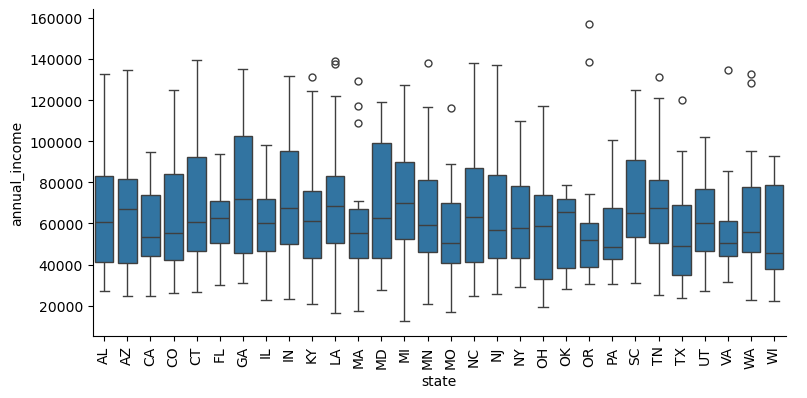

In [84]:
# Annual Income by state
g = sns.catplot(kind = 'box', data = profileData.sort_values(by = 'state', ascending = True), 
                x = 'state', y = 'annual_income', height = 4, aspect = 2)

for ax in g.axes.flat:
    ax.tick_params('x', labelrotation = 90)

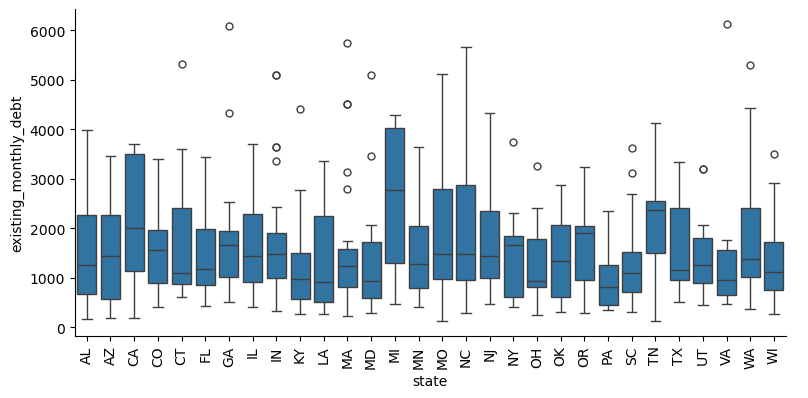

In [251]:
# Existing monthly debt by state
g = sns.catplot(kind = 'box', data = myData.sort_values(by = 'state', ascending = True), 
                x = 'state', y = 'existing_monthly_debt', height = 4, aspect = 2)

for ax in g.axes.flat:
    ax.tick_params('x', labelrotation = 90)

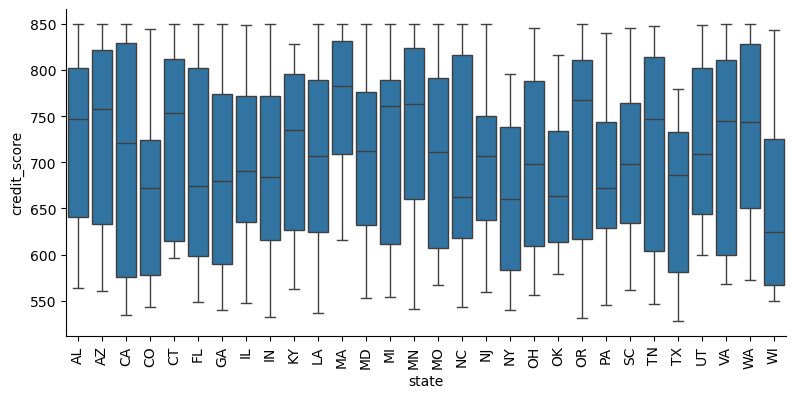

In [252]:
# Credit Scores by state
g = sns.catplot(kind = 'box', data = myData.sort_values(by = 'state', ascending = True), 
                x = 'state', y = 'credit_score', height = 4, aspect = 2)

for ax in g.axes.flat:
    ax.tick_params('x', labelrotation = 90)

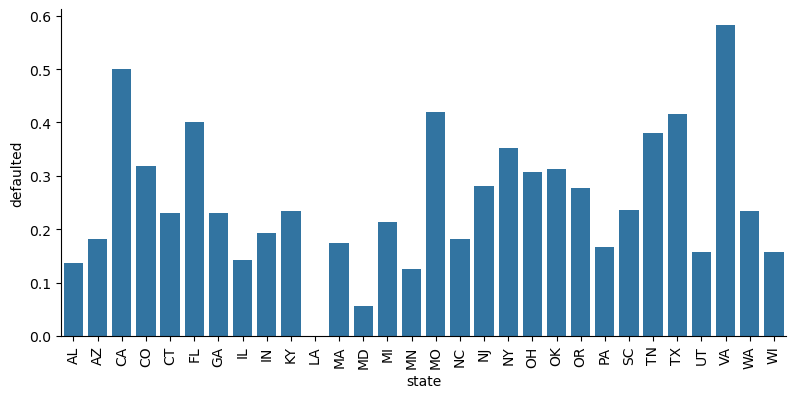

In [256]:
# Mean Default Rate by state
g = sns.catplot(kind = 'bar', data = myData.pivot_table(index = 'state', values = 'defaulted', aggfunc = 'mean')\
    .sort_values(by = 'state', ascending = True), x = 'state', y = 'defaulted', height = 4, aspect = 2)

for ax in g.axes.flat:
    ax.tick_params('x', labelrotation = 90)

# only a few states are within the 12% goal

In [262]:
# Avg default rate by state (numerical values to spot those near 12% goal)
myData.pivot_table(index = 'state', values = 'defaulted', aggfunc = 'mean')\
    .sort_values(by = 'state', ascending = True)
# LA, MD, and MN (borderline) are the only states under the default goal

,defaulted
state,
AL,0.136364
AZ,0.181818
CA,0.500000
CO,0.318182
CT,0.230769
FL,0.400000
GA,0.230769
IL,0.142857
IN,0.192308


### Assessments by Education Level

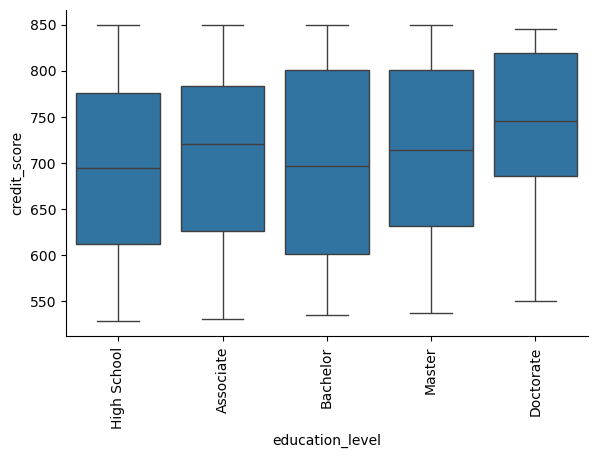

In [101]:
# Credit Score by Education Level
# create  sort order
education_order = {'High School' : 0,
                   'Associate' : 1,
                   'Bachelor' : 2,
                   'Master' : 3,
                   'Doctorate' : 4}

g = sns.catplot(kind = 'box', data = profileData.sort_values(by = 'education_level', key = lambda s: s.map(education_order)), 
                x = 'education_level', y = 'credit_score', height = 4, aspect = 1.5)

for ax in g.axes.flat:
    ax.tick_params('x', labelrotation = 90)

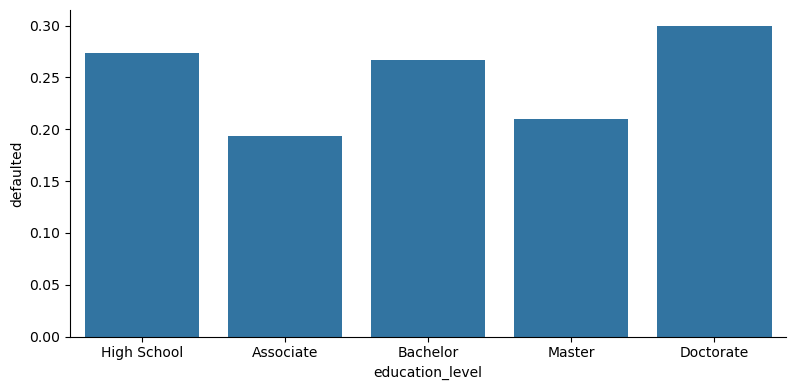

In [263]:
# Mean Default Rate by education level
# sort order
education_order = {'High School' : 0,
                   'Associate' : 1,
                   'Bachelor' : 2,
                   'Master' : 3,
                   'Doctorate' : 4}

g = sns.catplot(kind = 'bar', data = myData.pivot_table(index = 'education_level', values = 'defaulted', aggfunc = 'mean')\
                .sort_values(by = 'education_level', key = lambda s: s.map(education_order)),
                x = 'education_level', y = 'defaulted', height = 4, aspect = 2)

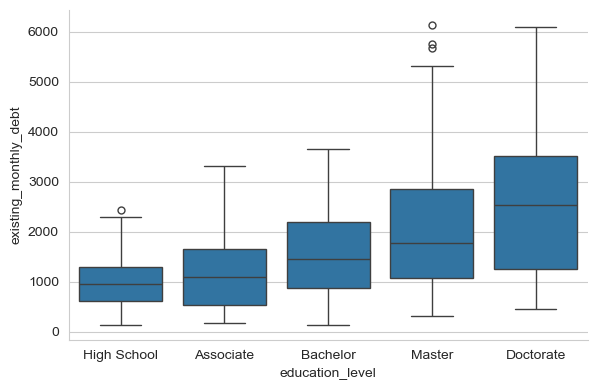

In [129]:
# Assess Existing monthly debt by education group
# create  sort order
education_order = {'High School' : 0,
                   'Associate' : 1,
                   'Bachelor' : 2,
                   'Master' : 3,
                   'Doctorate' : 4}

sns.catplot(kind = 'box', data = profileData.sort_values(by = 'education_level', key = lambda s: s.map(education_order)),
            x = 'education_level', y = 'existing_monthly_debt',
            height = 4, aspect = 1.5)

### Assessments by Employment Status

In [247]:
# calc default rate
myData.groupby('employment_status', observed = False)[['defaulted']].mean().sort_values('defaulted', ascending = False) 
# fairly even (all between 22-28%)

,defaulted
employment_status,
Part-Time,0.276923
Self-Employed,0.247619
Full-Time,0.239344
Retired,0.233333
Contract,0.227273


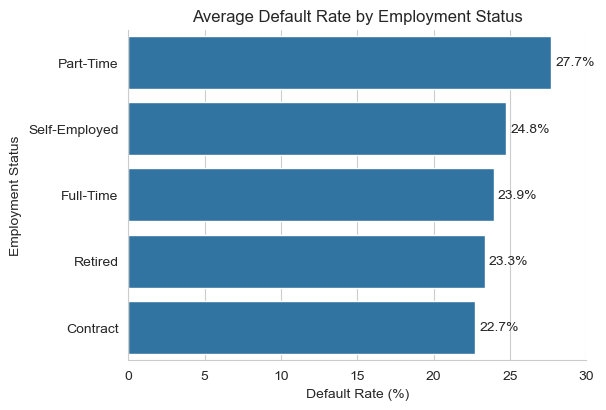

In [154]:
# create visual of rates by status
sns.set_style('whitegrid')

g = sns.catplot(myData.groupby('employment_status', observed = False)[['defaulted']]
    .mean().sort_values('defaulted', ascending = False) * 100, 
                kind = 'bar', y = 'employment_status', x = 'defaulted', 
                #hue = 'employment_status',
                height = 4, aspect = 1.5)

for ax in g.axes.flat:
    ax.set(title = 'Average Default Rate by Employment Status',
           xlabel = 'Default Rate (%)', ylabel = 'Employment Status',
          xlim = (0, 30))
    #ax.tick_params('x', labelrotation = 45)

    for container in ax.containers:
        labels = [f'{v.get_width():.1f}%' for v in container]
        ax.bar_label(container, labels=labels, padding=3)

g.savefig('avg_def_by_emp_status.png')

In [98]:
myData.pivot_table(index = 'employment_status', columns = 'cred_score_bin', values = 'defaulted', aggfunc = ['mean', 'count'], observed = False).round(3)

mean                                  count          \
cred_score_bin    520-599 600-649 650-699 700-749   750+ 520-599 600-649   
employment_status                                                          
Contract            0.467   0.333   0.000   0.182  0.095      15      12   
Full-Time           0.444   0.309   0.412   0.143  0.100      54      55   
Part-Time           0.583   0.200   0.286   0.364  0.056      12      10   
Retired             0.462   0.250   0.000   0.250  0.143      13       8   
Self-Employed       0.591   0.250   0.176   0.000  0.182      22       8   

                                        
cred_score_bin    650-699 700-749 750+  
employment_status                       
Contract                7      11   21  
Full-Time              34      42  120  
Part-Time              14      11   18  
Retired                 3       8   28  
Self-Employed          17      14   44

### Assessments by years employed

In [180]:
# identify averages by group and associated counts
myData.pivot_table(index = 'yrs_emp_bin',  values = 'defaulted', aggfunc = ['mean', 'count'], observed = False).round(3)

,mean,count
,defaulted,defaulted
yrs_emp_bin,,
<2 yr,0.345,84
2-5 yrs,0.175,114
6-10 yrs,0.262,126
10+ yrs,0.231,277


In [181]:
# roll up average data for comparison
print("Avg default <= 2 yrs: ", myData.query('years_employed <= 2')['defaulted'].mean().round(3) * 100) 
print("Avg default > 2 yrs: ", myData.query('years_employed > 2')['defaulted'].mean().round(3) * 100) 

Avg default <= 2 yrs:  31.1
Avg default > 2 yrs:  22.3


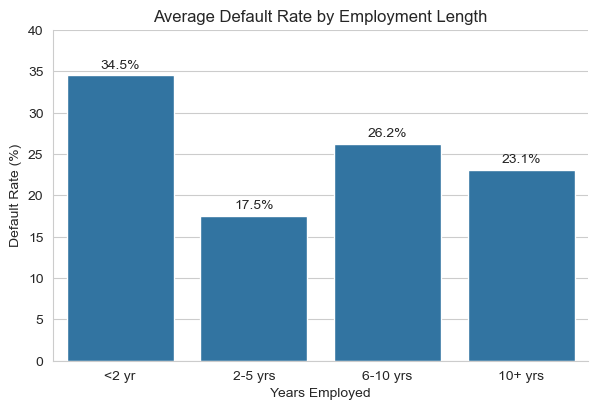

In [182]:
# plot avgs by grouping
sns.set_style('whitegrid')
#fig, ax = plt.subplots(figsize = (6, 4))

g = sns.catplot(data = myData.groupby('yrs_emp_bin', observed = False)[['defaulted']].mean() * 100,
                 x = 'yrs_emp_bin', y = 'defaulted', 
                 kind = 'bar', height = 4, aspect = 1.5
                 #hue = 'yrs_emp_bin'
                )
# modify title and axes
for ax in g.axes.flat:
    ax.set(title = 'Average Default Rate by Employment Length',
           xlabel = 'Years Employed', ylabel = 'Default Rate (%)',
           ylim = (0, 40))

    # add labels to bars
    for container in ax.containers:
        labels = [f'{v.get_height():.1f}%' for v in container]
        ax.bar_label(container, labels=labels, padding=3)

g.savefig('avg_def_by_emp_length.png')

In [194]:
avgDefYrsEmp = myData.groupby(['years_employed'], observed = False)[['defaulted']].mean() # very few years <= 12%
avgDefYrsEmp.head(10)

,defaulted
years_employed,
0,0.282051
1,0.400000
2,0.254902
3,0.166667
4,0.037037
5,0.125000
6,0.555556
7,0.086957
8,0.217391


In [184]:
#myData.groupby(['years_employed'], observed = False)[['defaulted']].mean() # fairly even (all between 22-28%)

# add count of records per group to assess relevancy
defRateByYearsEmp = (myData.groupby('years_employed', observed = False)\
                        .agg({'defaulted': 'mean', 'borrower_id': 'count'})\
                        .rename(columns = {'defaulted': 'Avg_Default_Rate', 'borrower_id' : 'Count'})) 

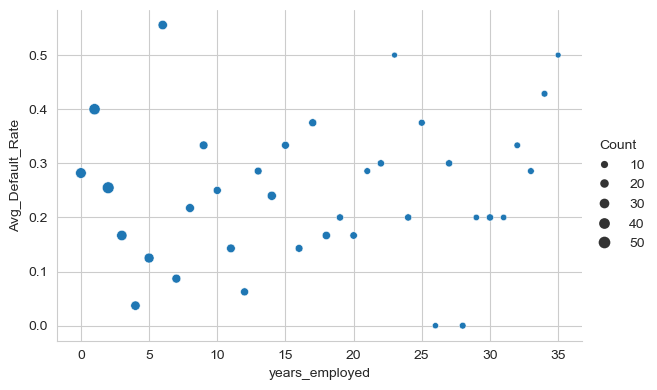

In [185]:
# visualization showing size of group per year employed and avg default rate
sns.relplot(data = defRateByYearsEmp, kind = 'scatter', size = 'Count', x = 'years_employed',
            y = 'Avg_Default_Rate', height = 4, aspect = 1.5)

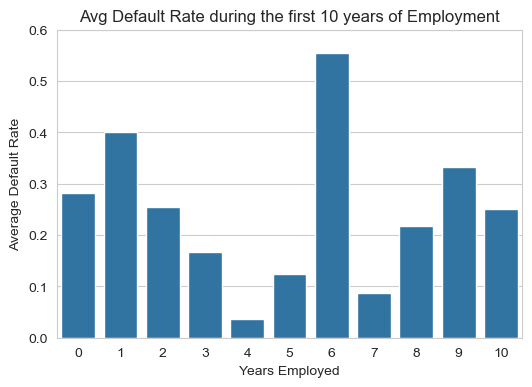

In [195]:
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize = (6, 4))

ax = sns.barplot(data = avgDefYrsEmp.query('years_employed <= 10'),
                x = 'years_employed', y = 'defaulted', #hue = 'yrs_emp_bin'
                )

ax.set(title = 'Avg Default Rate during the first 10 years of Employment',
       xlabel = 'Years Employed', ylabel = 'Average Default Rate',
      ylim = (0, 0.60))


fig.savefig('avg_def_by_yrs_emp_less_than_10.png')

[Text(0.5, 1.0, 'How do restrictions impact the results?'),
 Text(0.5, 0, 'Years Employed'),
 Text(0, 0.5, 'Average Default Rate'),
 (0.0, 0.6)]

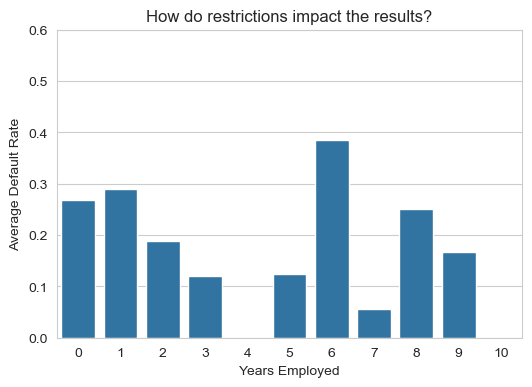

In [214]:
# assess how various metrics impact outcome of employment length rates

avgDefYrsEmpB = myData\
    .query('credit_score >= 650') \
    .groupby(['years_employed'], observed = False)[['defaulted']].mean() # very few years <= 12%
    
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize = (6, 4))

ax = sns.barplot(data = avgDefYrsEmpB.query('years_employed <= 10'),
                x = 'years_employed', y = 'defaulted', #hue = 'yrs_emp_bin'
                )

ax.set(#title = 'Credit score > 650 does not impact trend',
    title = 'How do restrictions impact the results?',
       xlabel = 'Years Employed', ylabel = 'Average Default Rate',
      ylim = (0, 0.6))

#### Default Rate by Years Employed groups

In [125]:
myData.pivot_table(index = 'yrs_emp_bin', columns = 'cred_score_bin', values = 'defaulted', aggfunc = ['mean', 'count'], observed = False).round(3)

mean                                  count                  \
cred_score_bin 520-599 600-649 650-699 700-749   750+ 520-599 600-649 650-699   
yrs_emp_bin                                                                     
<1 yr            0.750   0.600   0.750   0.333  0.167       4      10       4   
1-5 yrs          0.300   0.261   0.062   0.143  0.119      20      23      16   
6-10 yrs         0.531   0.500   0.385   0.333  0.067      32       8      13   
10+ yrs          0.549   0.208   0.270   0.086  0.100      51      48      37   

                             
cred_score_bin 700-749 750+  
yrs_emp_bin                  
<1 yr                9   18  
1-5 yrs             28   59  
6-10 yrs            12   45  
10+ yrs             35   90

In [153]:
# same query, using updated groups (<2 and 2-5 yrs in lieu of 1 yr)
myData.pivot_table(index = 'yrs_emp_bin', columns = 'cred_score_bin', 
                   values = 'defaulted', aggfunc = ['mean', 'count'], observed = False).round(3)

mean                                  count                  \
cred_score_bin 520-599 600-649 650-699 700-749   750+ 520-599 600-649 650-699   
yrs_emp_bin                                                                     
<2 yr            0.500   0.476   0.375   0.263  0.194      12      21       8   
2-5 yrs          0.250   0.167   0.083   0.111  0.073      12      12      12   
6-10 yrs         0.531   0.500   0.385   0.333  0.067      32       8      13   
10+ yrs          0.549   0.208   0.270   0.086  0.100      51      48      37   

                             
cred_score_bin 700-749 750+  
yrs_emp_bin                  
<2 yr               19   36  
2-5 yrs             18   41  
6-10 yrs            12   45  
10+ yrs             35   90

In [415]:
# Default Rate based on 2 year employment length
# add column to assign 2 year group
myData['less2yrs'] = myData.apply(lambda x: 1 if x.years_employed <= 2 else 0, axis = 1)
#myData.query('years_employed <= 2').head(10)

In [412]:
myData.groupby('less2yrs')['defaulted'].mean()

less2yrs
0    0.223176
1    0.311111
Name: defaulted, dtype: float64

### Assessments by Credit Score
##### Notes
##### * largest # of loans are for borrowers in 750+ group, which is also the only group that meets the 12% goal
##### * second largest # of loans are for borrowers in the 520-599 group, which also has the highest default rate
##### * These groups don't seem to be affected by the amount of the loan -- the average amount doesn't appear to have a trend
##### * If we remove the groups under 700, the default rate is 12.9%


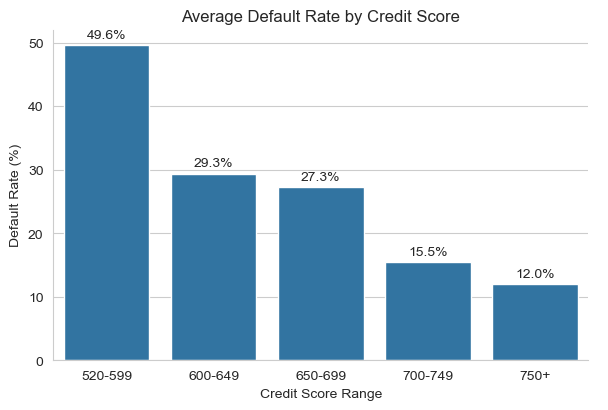

In [145]:
# Mean Default Rate by credit score
sns.set_style('whitegrid')

g = sns.catplot(data = myData.groupby('cred_score_bin', observed = False)[['defaulted']].mean() * 100, 
                kind = 'bar', x = 'cred_score_bin', y = 'defaulted', 
                #hue = 'cred_score_bin',
                height = 4, aspect =  1.5)

for ax in g.axes.flat:
    ax.set(title = 'Average Default Rate by Credit Score',
           ylabel = 'Default Rate (%)', xlabel = 'Credit Score Range')

    # add labels for each bar
    for container in ax.containers:
        #labels = [f'{v.get_height():.1%}' for v in container]
        ax.bar_label(container, labels=labels, padding=3)

g.savefig('avg_def_by_cred_score.png')

In [283]:
myData.groupby('cred_score_bin', observed = False)[['defaulted']].mean()
# note -- credit score ranges (such as those defined by Experian) change the distribution of default rate

,defaulted
cred_score_bin,
520-599,0.495652
600-649,0.293478
650-699,0.272727
700-749,0.154762
750+,0.120172


In [18]:
#myData.groupby('cred_score_bin', observed = False)[['borrower_id']].count()
myData.groupby('cred_score_bin', observed = False)['borrower_id'].nunique()

cred_score_bin
520-599     96
600-649     74
650-699     67
700-749     72
750+       191
Name: borrower_id, dtype: int64

<Axes: title={'center': 'Count of Borrowers'}, xlabel='cred_score_bin'>

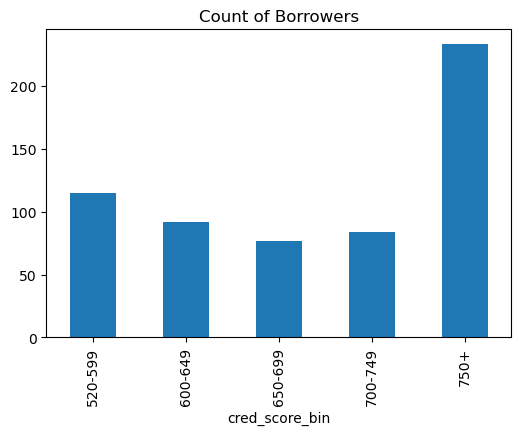

In [277]:
# Count # of borrowers per bin
fig, ax = plt.subplots(figsize = (6, 4))

myData.groupby('cred_score_bin', observed = False)[['borrower_id']].count() \
    .plot.bar(ax = ax, title = 'Count of Borrowers', legend = False)

In [20]:
# get counts and loan amounts (on a loan basis -- not borrower basis)
summary = (myData.groupby(['cred_score_bin', 'defaulted'], observed=False).agg({'defaulted': 'count',
                                                                                #'loan_amount': 'sum'
                                                                                'loan_amount': 'mean'
                                                                               }).unstack())

summary.style.format({
    ('defaulted', True): '{:,}',
    ('defaulted', False): '{:,}',
    ('loan_amount', True): '${:,.0f}',
    ('loan_amount', False): '${:,.0f}'
})

In [29]:
# Calc avg loan amounts
# avg loan by credit score bin
summary = (myData.groupby(['cred_score_bin'], observed=False).agg({'loan_amount': 'mean'}).unstack())

# avg loan by default type
#summary = (myData.groupby(['defaulted'], observed=False).agg({'loan_amount': 'mean'}).unstack())

# avg loan in general
#summary = myData.loan_amount.mean()
summary

             cred_score_bin
loan_amount  520-599           23481.739130
             600-649           19475.000000
             650-699           22332.467532
             700-749           21952.380952
             750+              22555.364807
dtype: float64

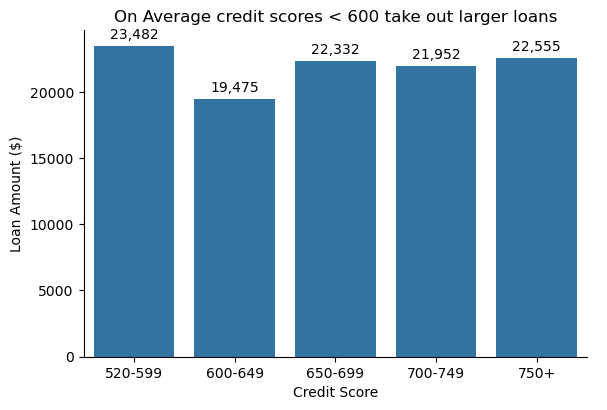

In [77]:
#graph of average loan amounts
g = sns.catplot(data = myData.groupby('cred_score_bin', observed = False)[['loan_amount']].mean(), 
            kind = 'bar', height = 4, aspect = 1.5, 
            x = 'cred_score_bin', y = 'loan_amount')

for ax in g.axes.flat:
    ax.set(title = 'On Average credit scores < 600 take out larger loans',
           xlabel = 'Credit Score',
           ylabel = 'Loan Amount ($)')
    
    # add labels for each bar
    for container in ax.containers:
        labels = [f'{v.get_height():,.0f}' for v in container]
        ax.bar_label(container, labels=labels, padding=3)

g.savefig('avg_loan_by_cred_score.png')

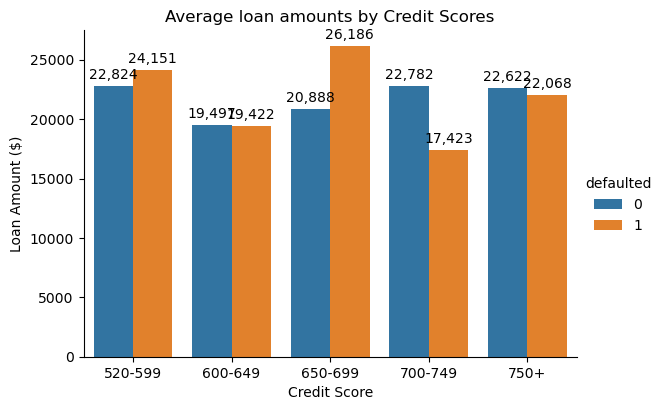

In [76]:
#graph of average loan amounts
g = sns.catplot(data = myData.groupby(['cred_score_bin', 'defaulted'], observed = False)[['loan_amount']].mean(), 
            kind = 'bar', height = 4, aspect = 1.5, hue = 'defaulted',
            x = 'cred_score_bin', y = 'loan_amount')

for ax in g.axes.flat:
    ax.set(title = 'Average loan amounts by Credit Scores',
           xlabel = 'Credit Score',
           ylabel = 'Loan Amount ($)')
    
    # add labels for each bar
    for container in ax.containers:
        labels = [f'{v.get_height():,.0f}' for v in container]
        ax.bar_label(container, labels=labels, padding=3)

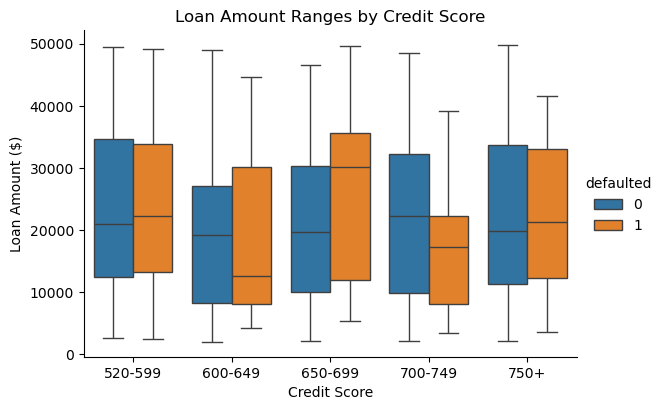

In [53]:
# box plots to show range of loan amount data by credit score
g = sns.catplot(data = myData,
            kind = 'box', height = 4, aspect = 1.5, hue = 'defaulted',
            x = 'cred_score_bin', y = 'loan_amount')

for ax in g.axes.flat:
    ax.set(title = 'Loan Amount Ranges by Credit Score',
           xlabel = 'Credit Score',
           ylabel = 'Loan Amount ($)')
    
# note - box plot displays median not mean

In [59]:
# avg default rate without < 600 credit score
myData.query('cred_score_bin != "520-599"')['defaulted'].mean().round(3)

np.float64(0.183)

In [60]:
# avg default rate without < 650 credit score
myData.query('cred_score_bin not in ("520-599", "600-649") ')['defaulted'].mean().round(3)

np.float64(0.157)

In [61]:
# avg default rate without < 700 credit score
myData.query('cred_score_bin not in ("520-599", "600-649", "650-699") ')['defaulted'].mean().round(3)

np.float64(0.129)

In [95]:
# avg default rate for > 700 credit score
myData.query('cred_score_bin in ("520-599", "600-649", "650-699") ')['defaulted'].mean().round(3)

np.float64(0.37)

### Assessments by Home Ownership

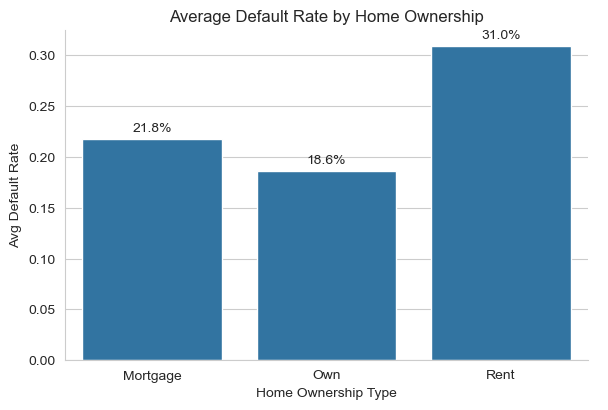

In [317]:
# Mean Default Rate by home ownership
sns.set_style('whitegrid')

g = sns.catplot(data = myData.groupby('home_ownership', observed = False)[['defaulted']].mean(), 
                kind = 'bar', x = 'home_ownership', y = 'defaulted', 
                #hue = 'cred_score_bin',
                height = 4, aspect =  1.5)

for ax in g.axes.flat:
    ax.set(title = 'Average Default Rate by Home Ownership',
           ylabel = 'Avg Default Rate', xlabel = 'Home Ownership Type')

    # add labels for each bar
    for container in ax.containers:
        labels = [f'{v.get_height():.1%}' for v in container]
        ax.bar_label(container, labels=labels, padding=3)

#g.savefig('avg_def_by_cred_score.png')

In [18]:
# Avg monthly debt based on home ownership
profileData.groupby('home_ownership')['existing_monthly_debt'].mean().round(2)

home_ownership
Mortgage    1559.31
Own         1503.87
Rent        1665.86
Name: existing_monthly_debt, dtype: float64

### Assessments by Dependents


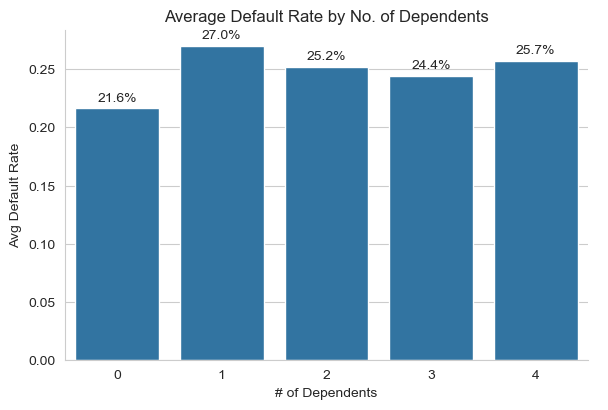

In [319]:
# Mean Default Rate by number of dependents
sns.set_style('whitegrid')

g = sns.catplot(data = myData.groupby('dependents', observed = False)[['defaulted']].mean(), 
                kind = 'bar', x = 'dependents', y = 'defaulted', 
                height = 4, aspect =  1.5)

for ax in g.axes.flat:
    ax.set(title = 'Average Default Rate by No. of Dependents',
           ylabel = 'Avg Default Rate', xlabel = '# of Dependents')

    # add labels for each bar
    for container in ax.containers:
        labels = [f'{v.get_height():.1%}' for v in container]
        ax.bar_label(container, labels=labels, padding=3)

### Assessments by Existing Monthly Debt

In [340]:
# create bins for existing monthly debt
myData['debt_bins'] = pd.cut(myData.existing_monthly_debt, bins = 10, right = False)
myData.debt_bins.value_counts()

debt_bins
[724.6, 1325.2)       165
[124.0, 724.6)        136
[1325.2, 1925.8)      117
[1925.8, 2526.4)       80
[2526.4, 3127.0)       36
[3127.0, 3727.6)       36
[3727.6, 4328.2)       13
[4928.8, 5529.4)        7
[4328.2, 4928.8)        6
[5529.4, 6136.006)      5
Name: count, dtype: int64

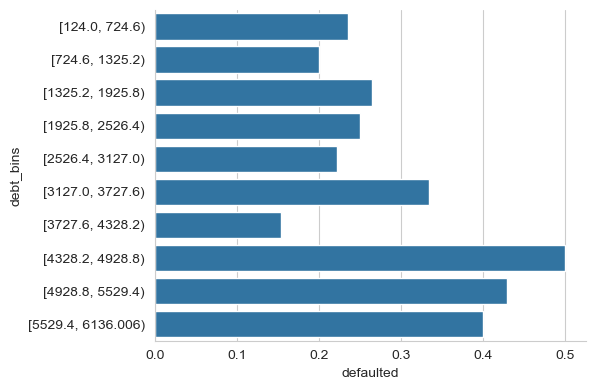

In [392]:
# Mean Default Rate by number of Existing Monthly Debt
sns.set_style('whitegrid')

g = sns.catplot(data = myData.groupby('debt_bins', observed = False)[['defaulted']].mean(), 
                kind = 'bar', y = 'debt_bins', x = 'defaulted', 
                height = 4, aspect =  1.5)

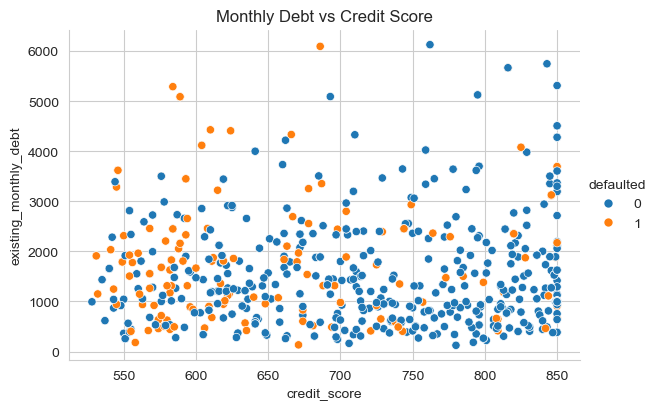

In [382]:
# Are there any trends between existing monthly debt, credit score, and default?
sns.set_style('whitegrid')
   
g = sns.relplot(data = myData, kind = 'scatter',
                x = 'credit_score', y = 'existing_monthly_debt', 
                height = 4, aspect = 1.5,
                hue = 'defaulted')

for ax in g.axes.flat:
    ax.set(title = 'Monthly Debt vs Credit Score')
# there does appear to be more orange dots on the left side of the plot (550-625 credit score range)

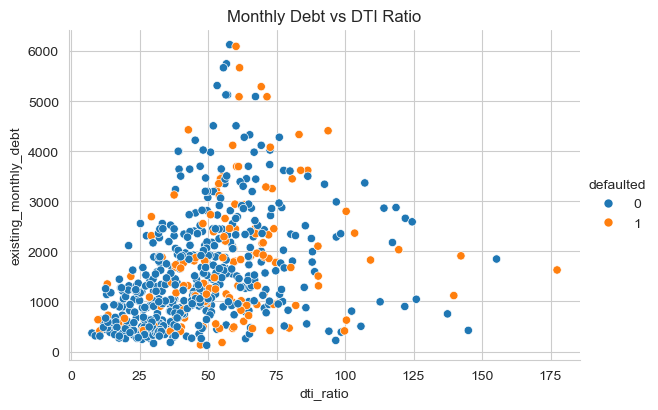

In [366]:
# Are there any trends between existing monthly debt, DTI, and default?
sns.set_style('whitegrid')
   
g = sns.relplot(data = myData, kind = 'scatter',
                x = 'dti_ratio', y = 'existing_monthly_debt', 
                height = 4, aspect = 1.5,
                hue = 'defaulted')

for ax in g.axes.flat:
    ax.set(title = 'Monthly Debt vs DTI Ratio')

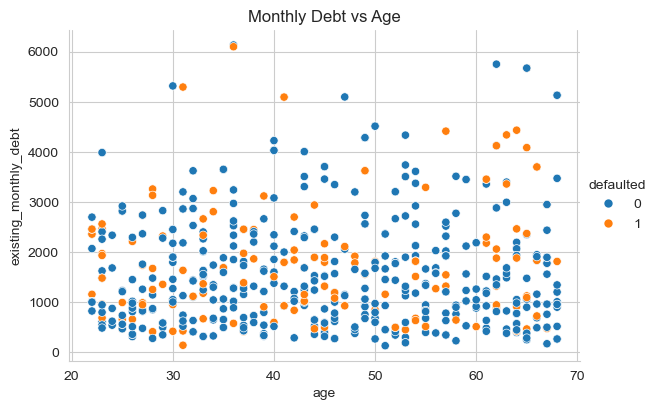

In [367]:
# Are there any trends between existing monthly debt, age, and default?
sns.set_style('whitegrid')
   
g = sns.relplot(data = myData, kind = 'scatter',
                x = 'age', y = 'existing_monthly_debt', 
                height = 4, aspect = 1.5,
                hue = 'defaulted')

for ax in g.axes.flat:
    ax.set(title = 'Monthly Debt vs Age')

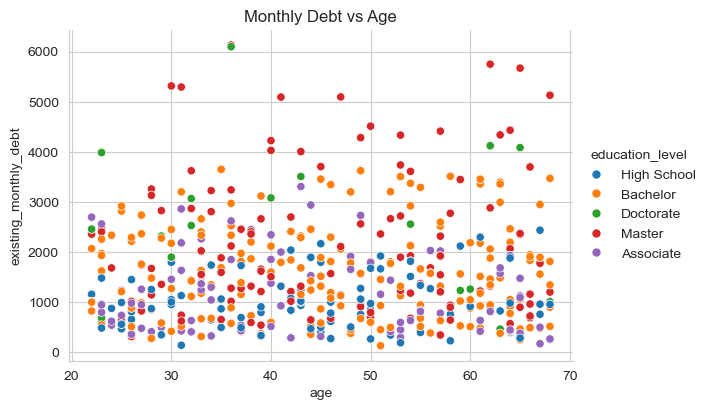

In [374]:
# Are there any trends between existing monthly debt, age, and education level?
sns.set_style('whitegrid')
   
g = sns.relplot(data = myData, kind = 'scatter',
            x = 'age', y = 'existing_monthly_debt', 
            height = 4, aspect = 1.5,
            hue = 'education_level')            

for ax in g.axes.flat:
    ax.set(title = 'Monthly Debt vs Age')

### Assessments by Application Date

### Assess application Date

In [456]:
defaultedCounts = myData.pivot_table(index = 'application_date', 
                                     values = 'borrower_id',
                                     columns = 'defaulted', 
                                     aggfunc = 'count')
defaultedCounts.head()

defaulted,0,1
application_date,,
2024-01-02,1.0,NaN
2024-01-04,1.0,NaN
2024-01-05,3.0,NaN
2024-01-06,3.0,NaN
2024-01-07,1.0,NaN


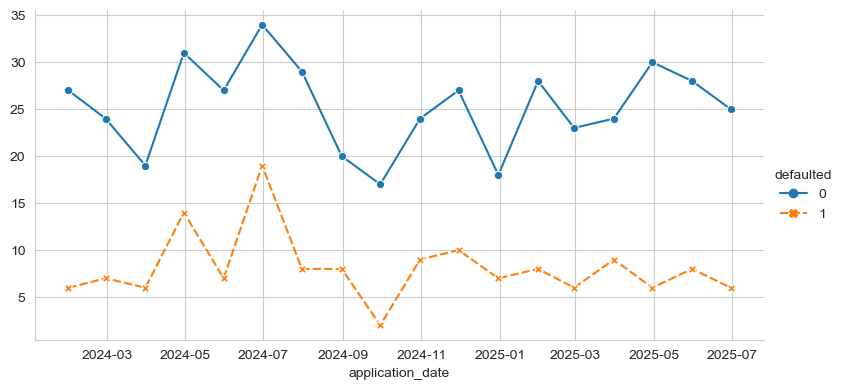

In [472]:
countsByMonth = defaultedCounts.resample(rule = 'ME').sum()
#countsByMonth.plot.line(title = 'Counts by Default Type over Time')
sns.relplot(data = countsByMonth, kind = 'line', markers = True, height = 4, aspect = 2)


### Assessments by Loan Purpose

In [83]:
(myData.groupby('loan_purpose', observed = False)[['defaulted']]
    .mean()
    .sort_values('defaulted', ascending = False)
    .mul(100)
    .round(1)) 
# fairly even across all cats


,defaulted
loan_purpose,
Wedding,32.1
Home Improvement,28.6
Auto Loan,27.1
Business Loan,24.1
Education,22.6
Vacation,22.6
Major Purchase,22.1
Debt Consolidation,21.6
Moving,21.4


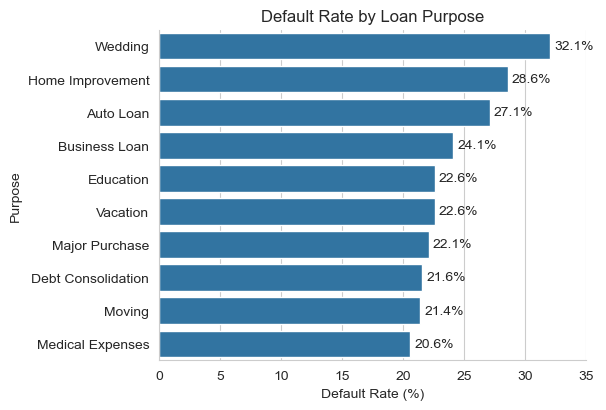

In [152]:
# create visual
sns.set_style('whitegrid')
g = sns.catplot(data = myData.groupby('loan_purpose', observed = False)[['defaulted']]
    .mean().sort_values('defaulted', ascending = False).mul(100).round(1),   # multiply results by 100 and use 1 decimal for output display
                y = 'loan_purpose', kind = 'bar', 
                #hue = 'loan_purpose',
                x = 'defaulted', height = 4, aspect = 1.5)
for ax in g.axes.flat:
    ax.set(title = 'Default Rate by Loan Purpose', 
           xlabel = 'Default Rate (%)', ylabel = 'Purpose',
           xlim = (0,35))
    #ax.tick_params('x', labelrotation = 90)

    for container in ax.containers:
        #labels = [f'{v.get_width():.1%}' for v in container] # width for hbar plots
        ax.bar_label(container, fmt = '%.1f%%', padding=3)   

g.savefig('avg_def_by_purpose.png')

<Axes: xlabel='cred_score_bin', ylabel='loan_purpose'>

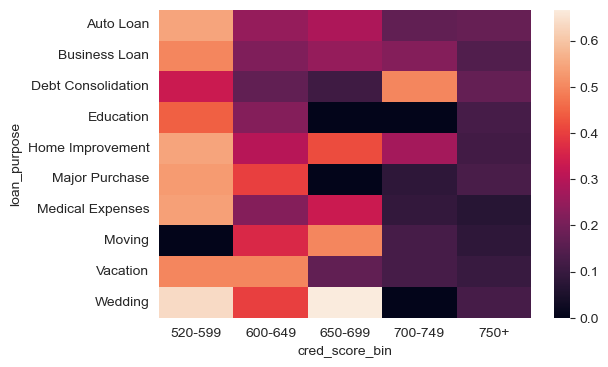

In [423]:
# Compare default rate with loan purpose AND credit score groups
#myData.pivot_table(index = 'loan_purpose', columns = 'cred_score_bin', values = 'defaulted', aggfunc = ['mean', 'count'], observed = False).round(3)
sns.heatmap(data = myData.pivot_table(index = 'loan_purpose', columns = 'cred_score_bin', 
                                      values = 'defaulted', aggfunc = 'mean', observed = False).round(3))

In [422]:
with pd.option_context('display.max_columns', None):
    #display(myData.query('loan_purpose == "Debt Consolidation" and cred_score_bin == "700-749"')) # DTI ratios are 40-74 here (pretty high!)
    display(myData.query('loan_purpose == "Moving" and cred_score_bin == "650-699"')) # 3 (out of 10) DTI ratios are greater than 50 here (pretty high!)

,index,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt,age_bin,loan_id,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted,cred_score_bin,dti_bin,yrs_emp_bin,int_rate_bin,loan_number,loan_end_date,previous_loan_end_date,opened_before_previous_paid_off,debt_bins,less2yrs
28,21,BRW-0022,65,OH,Bachelor,Part-Time,6,24456,698,Own,1,244,60s,LN-00029,2024-02-08,Moving,13600.0,60,9.14,283.24,25.9,Current,0,0,650-699,26-35%,6-10 yrs,9%,2,2029-02-08,2026-01-23,True,"[124.0, 724.6)",0
36,28,BRW-0029,42,MN,Master,Full-Time,8,116049,667,Mortgage,2,2694,40s,LN-00037,2024-04-01,Moving,5400.0,48,10.50,138.26,29.3,Default,135,1,650-699,26-35%,6-10 yrs,10%,1,2028-04-01,NaT,False,"[2526.4, 3127.0)",0
65,52,BRW-0053,55,NJ,Bachelor,Full-Time,15,68663,681,Mortgage,3,516,50s,LN-00066,2024-12-23,Moving,12000.0,24,9.39,550.37,18.6,Default,38,1,650-699,0-25%,10+ yrs,9%,1,2026-12-23,NaT,False,"[124.0, 724.6)",0
92,73,BRW-0074,45,MO,High School,Full-Time,1,41201,670,Rent,0,1792,40s,LN-00093,2025-02-27,Moving,35700.0,60,11.14,778.70,74.9,Default,92,1,650-699,>51%,<2 yr,11%,1,2030-02-27,NaT,False,"[1325.2, 1925.8)",1
150,123,BRW-0124,51,IL,Bachelor,Self-Employed,16,60540,695,Mortgage,2,1448,50s,LN-00151,2024-04-10,Moving,11900.0,48,12.47,316.13,35.0,Current,0,0,650-699,36-45%,10+ yrs,12%,1,2028-04-10,NaT,False,"[1325.2, 1925.8)",0
187,154,BRW-0155,32,OK,Master,Contract,0,66474,663,Mortgage,1,2864,30s,LN-00189,2024-11-04,Moving,24500.0,36,9.17,781.03,65.8,Paid Off,0,0,650-699,>51%,<2 yr,9%,2,2027-11-04,NaT,False,"[2526.4, 3127.0)",1
298,246,BRW-0247,66,UT,High School,Full-Time,6,37673,694,Rent,0,488,60s,LN-00299,2024-11-29,Moving,31000.0,48,9.18,774.09,40.2,Default,134,1,650-699,36-45%,6-10 yrs,9%,1,2028-11-29,NaT,False,"[124.0, 724.6)",0
398,330,BRW-0331,36,GA,Doctorate,Full-Time,1,135142,686,Rent,2,6096,30s,LN-00399,2024-04-01,Moving,20400.0,36,12.24,679.91,60.2,Default,176,1,650-699,>51%,<2 yr,12%,1,2027-04-01,NaT,False,"[5529.4, 6136.006)",1
430,358,BRW-0359,66,UT,Bachelor,Full-Time,3,96677,661,Rent,0,1903,60s,LN-00431,2024-04-06,Moving,30200.0,60,11.38,662.36,31.8,Current,0,0,650-699,26-35%,2-5 yrs,11%,1,2029-04-06,NaT,False,"[1325.2, 1925.8)",0
531,444,BRW-0445,45,IN,Bachelor,Contract,4,78216,683,Mortgage,0,1511,40s,LN-00532,2024-07-14,Moving,30800.0,24,10.36,1426.39,45.1,Current,0,0,650-699,46-50%,2-5 yrs,10%,1,2026-07-14,NaT,False,"[1325.2, 1925.8)",0


### Assessments by Loan Amount

In [174]:
# average loan amount by default status
myData[['loan_amount']].mean().round(2)

loan_amount    22148.25
dtype: float64

In [172]:
# average loan amount by default status
myData.groupby('defaulted')[['loan_amount']].mean().round(2)

,loan_amount
defaulted,
0,22012.75
1,22570.55


In [173]:
22570.55-22012.75

557.7999999999993

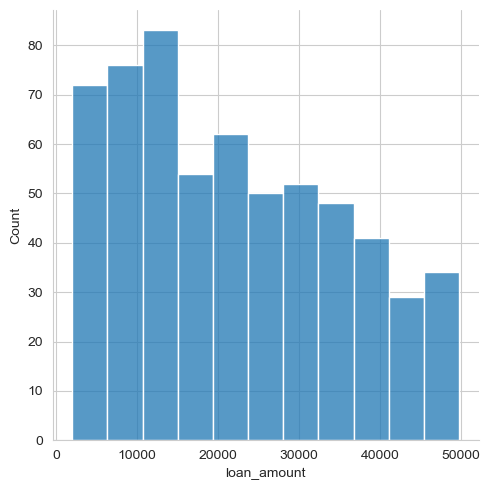

In [481]:
sns.displot(kind = 'hist', data = myData, x = 'loan_amount')

In [488]:
myData['loan_amt_bin'] = pd.cut(myData.loan_amount, bins = [0, 5000, 10000, 15000, 20000, 25000, 30000, 35000, 40000, 45000, 50000, 100000], 
                                labels = ['0-4.9k', '5-9.9k', '10-14.9k', '15-19.9k', '20-24.9k', '25-29.9k', '30-34.9k', '35-39.9k', '40-44.9k', '45-49.9k', '50k+'], right = False)

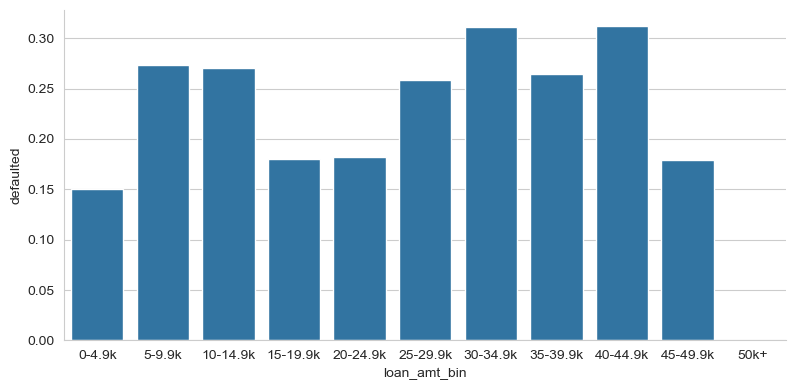

In [491]:
g = sns.catplot(data = myData.groupby('loan_amt_bin', observed = False)[['defaulted']].mean(), 
                kind = 'bar', x = 'loan_amt_bin', y = 'defaulted', 
                height = 4, aspect =  2)

### Assessments by Term Months

In [ ]:
# skipped

### Assessments by Interest Rate
##### Notes
##### * Data appears normally distributed
##### * Average default rates by range groupings are fairly flat until the 14% mark where rates jump drastically
##### * Comparing interest rate and credit score, there appear to be more defaults for lower credit scores and higher interest rates, and the opposite is true for DTI where higher DTI and interest rates show higher frequency of default than lower DTI.

In [70]:
myData.interest_rate.describe()

count    601.000000
mean      10.641331
std        2.251153
min        5.860000
25%        8.940000
50%       10.540000
75%       12.330000
max       15.860000
Name: interest_rate, dtype: float64

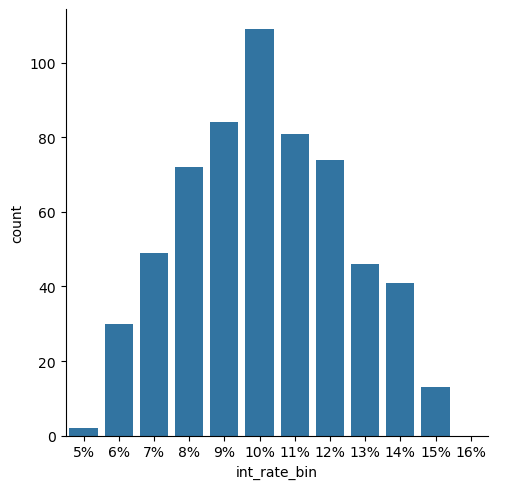

In [74]:
sns.catplot(data = myData,
            kind = 'count', x = 'int_rate_bin')

In [397]:
# default rate by interest rate
myData.groupby('int_rate_bin', observed = False)[['defaulted']].mean()

,defaulted
int_rate_bin,
5%,0.000000
6%,0.233333
7%,0.183673
8%,0.097222
9%,0.214286
10%,0.211009
11%,0.271605
12%,0.256757
13%,0.239130


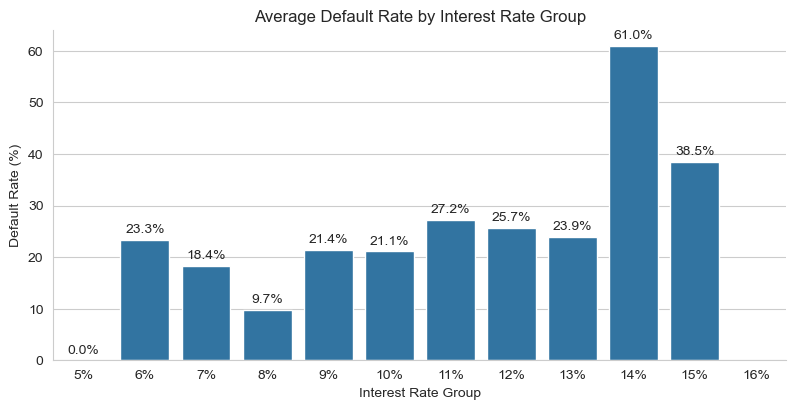

In [144]:
# default rate by interest rate plot
sns.set_style('whitegrid')
g = sns.catplot(data = myData.groupby('int_rate_bin', observed = False)[['defaulted']].mean()*100,
                kind = 'bar', x = 'int_rate_bin', y = 'defaulted',
                height = 4, aspect = 2)

for ax in g.axes.flat:
    ax.set(title = 'Average Default Rate by Interest Rate Group',
          xlabel = 'Interest Rate Group',
          ylabel = 'Default Rate (%)')

    # Add labels to each bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3)
    
g.savefig('Avg_def_rate_by_int_rate.png')

In [82]:
# average default rate for interest rates less than 14%
myData.query('interest_rate < 14')[['defaulted']].mean()

defaulted    0.212066
dtype: float64

In [83]:
# average default rate for interest rates greater than 14%
myData.query('interest_rate >= 14')[['defaulted']].mean()

defaulted    0.555556
dtype: float64

In [556]:
# get counts and loan amounts 
summary = (myData.groupby(['int_rate_bin', 'defaulted'], observed=False).agg({'defaulted': 'count',
                                                                                'loan_amount': 'sum'
                                                                                #'loan_amount': 'mean'
                                                                               }).unstack())

summary.style.format({
    ('defaulted', True): '{:,}',
    ('defaulted', False): '{:,}',
    ('loan_amount', True): '${:,.0f}',
    ('loan_amount', False): '${:,.0f}'
})

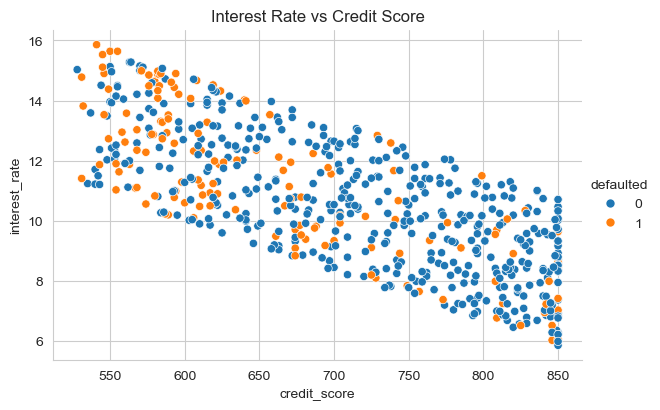

In [386]:
# Are there any trends between credit score, interest rate, and default?
sns.set_style('whitegrid')
   
g = sns.relplot(data = myData, kind = 'scatter',
                y = 'interest_rate', x = 'credit_score', 
                height = 4, aspect = 1.5,
                hue = 'defaulted')

for ax in g.axes.flat:
    ax.set(title = 'Interest Rate vs Credit Score')
# this shows the range of interest rate per credit score.
# There are more orange dots (defaults) at the bottom (lower credit score), but the highest credit scores still have defaults.

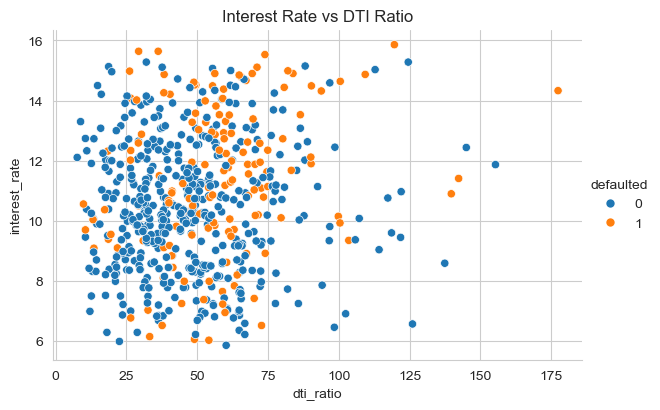

In [387]:
# Are there any trends between dti, interest rate, and default?
sns.set_style('whitegrid')
   
g = sns.relplot(data = myData, kind = 'scatter',
                y = 'interest_rate', x = 'dti_ratio', 
                height = 4, aspect = 1.5,
                hue = 'defaulted')
for ax in g.axes.flat:
    ax.set(title = 'Interest Rate vs DTI Ratio')
# most of the DTI values are 75 or below
# higher interest rates and higher DTI have more frequent defaults

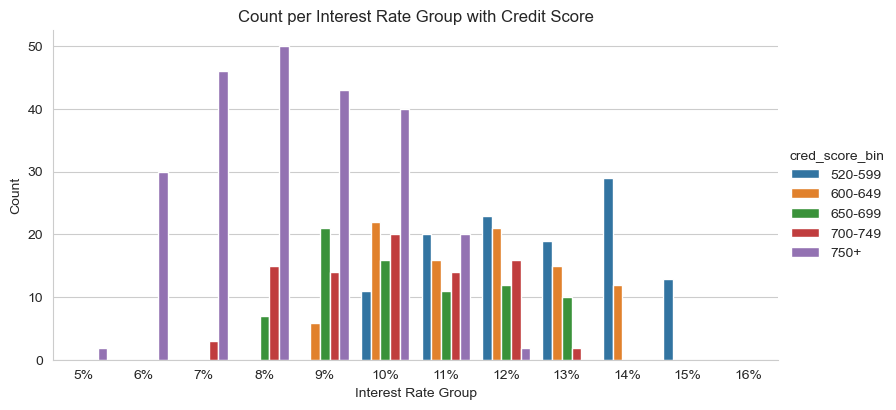

In [126]:
# count of credit scores by interest rate
sns.set_style('whitegrid')
g = sns.catplot(data = myData, hue = 'cred_score_bin',
                kind = 'count', x = 'int_rate_bin', 
                #col = 'defaulted', col_wrap = 1,
                height = 4, aspect = 2)
for ax in g.axes.flat:
    ax.set(title = 'Count per Interest Rate Group with Credit Score',
          xlabel = 'Interest Rate Group',
          ylabel = 'Count')

#g.savefig('Avg_def_rate_by_int_rate.png')

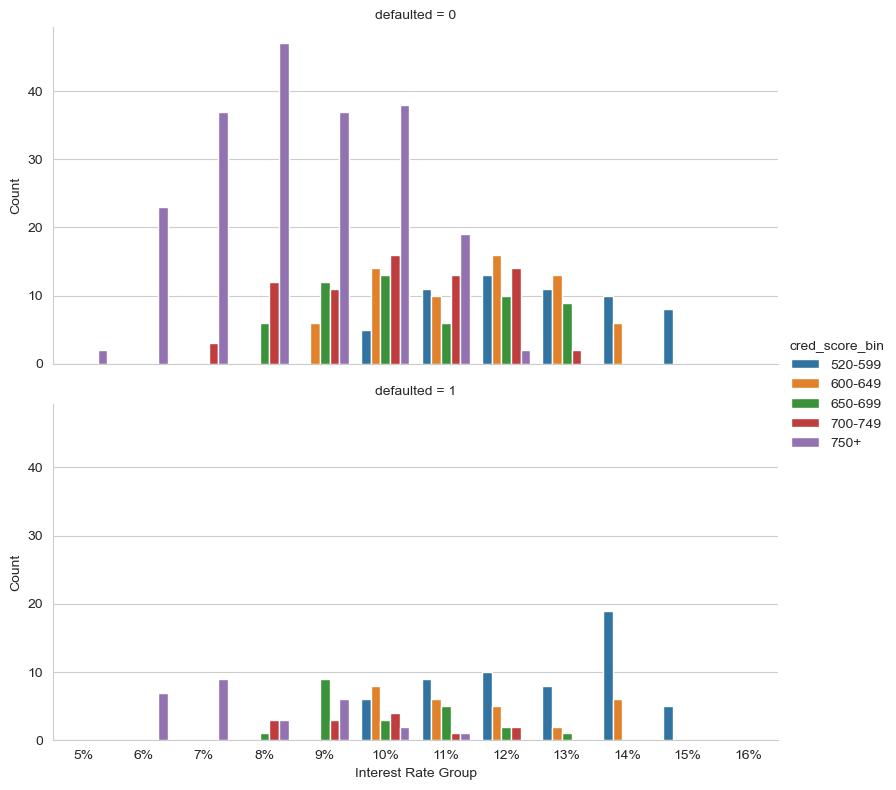

In [118]:
# count of credit scores by interest rate
sns.set_style('whitegrid')
g = sns.catplot(data = myData, hue = 'cred_score_bin',
                kind = 'count', x = 'int_rate_bin', 
                col = 'defaulted', col_wrap = 1,
                height = 4, aspect = 2)
for ax in g.axes.flat:
    ax.set(#title = 'Count per Interest Rate Group with Credit Score',
          xlabel = 'Interest Rate Group',
          ylabel = 'Count')

#g.savefig('Avg_def_rate_by_int_rate.png')

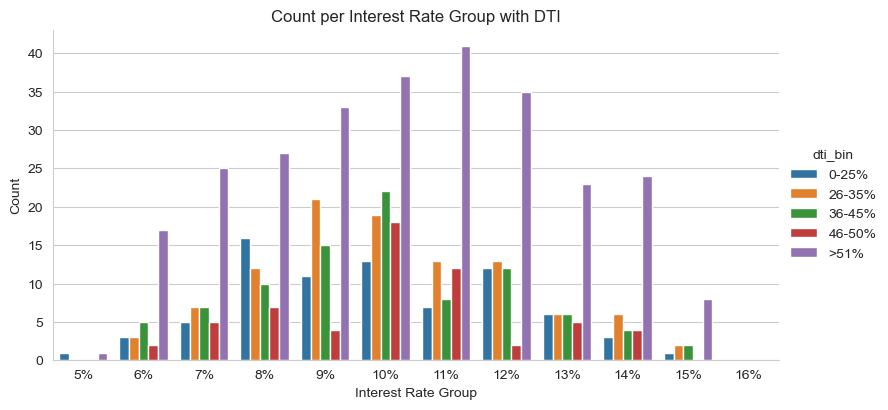

In [125]:
# count of interest rate by dti
sns.set_style('whitegrid')
g = sns.catplot(data = myData, 
                kind = 'count', x = 'int_rate_bin', 
                hue = 'dti_bin', 
                #col = 'defaulted', col_wrap = 1,
                height = 4, aspect = 2)
for ax in g.axes.flat:
    ax.set(title = 'Count per Interest Rate Group with DTI',
          xlabel = 'Interest Rate Group',
          ylabel = 'Count')

#g.savefig('Avg_def_rate_by_int_rate.png')

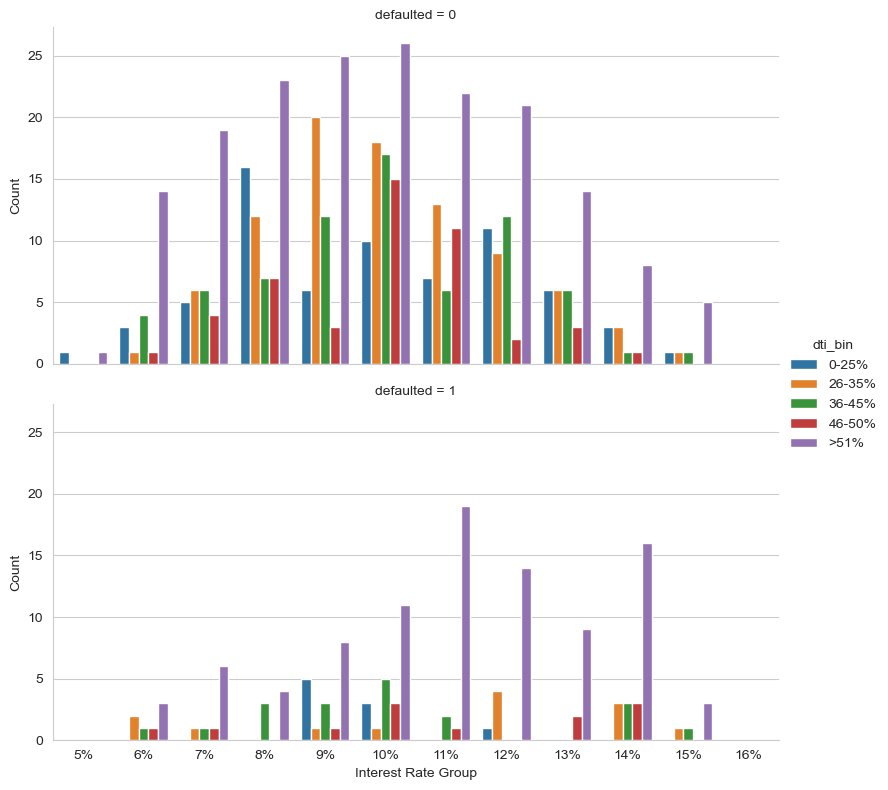

In [119]:
# count of interest rate by dti
sns.set_style('whitegrid')
g = sns.catplot(data = myData, 
                kind = 'count', x = 'int_rate_bin', 
                hue = 'dti_bin', 
                col = 'defaulted', col_wrap = 1,
                height = 4, aspect = 2)
for ax in g.axes.flat:
    ax.set(#title = 'Count per Interest Rate Group with DTI',
          xlabel = 'Interest Rate Group',
          ylabel = 'Count')

#g.savefig('Avg_def_rate_by_int_rate.png')

### Assessment by monthly payment

In [ ]:
# skipped

### Assessments by DTI

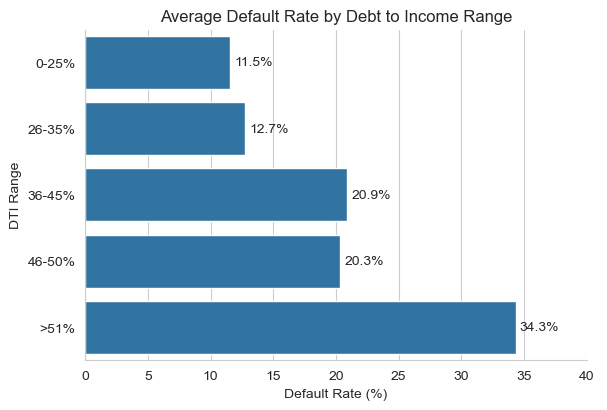

In [151]:
# create visual for default rate by DTI 
sns.set_style('whitegrid')
g = sns.catplot(data = myData.groupby('dti_bin', observed = False)[['defaulted']].mean() * 100, 
            kind = 'bar', y = 'dti_bin', x = 'defaulted', 
                #hue = 'dti_bin',
               height = 4, aspect = 1.5)

for ax in g.axes.flat:
    ax.set(title = 'Average Default Rate by Debt to Income Range',
           xlabel = 'Default Rate (%)', ylabel = 'DTI Range',
           xlim = (0, 40))
    #ax.tick_params('x', labelrotation = 45)

    for container in ax.containers:
        labels = [f'{v.get_width():.1f}%' for v in container]
        ax.bar_label(container, labels=labels, padding=3)    

g.savefig('avg_def_by_dti.png')


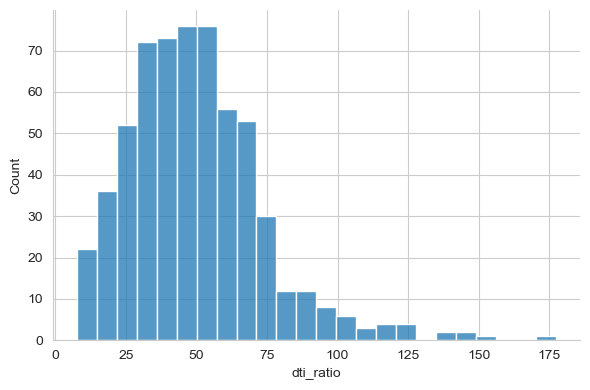

In [92]:
# assess distribution of DTI data
sns.displot(data = myData, kind = 'hist', x = 'dti_ratio', height = 4, aspect = 1.5)

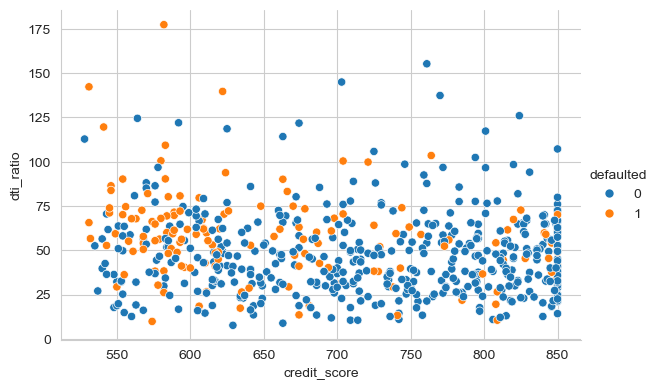

In [164]:
# credit score vs Default status
# Note -- used strip plot to jitter points and make them more visible
g = sns.relplot(data = myData, kind = 'scatter',
                #kind = 'strip', 
                x = 'credit_score', y = 'dti_ratio', 
                height = 4, aspect = 1.5, 
                hue = 'defaulted'
                #hue = 'interest_rate'
                #hue = 'age_bin'
                #hue = 'education_level'
               )
                    
#for ax in g.axes.flat:
#    ax.set(title = 'DTI Ratio vs Default status', 
#ylabel = 'DTI ratio', xlabel = 'Default status')

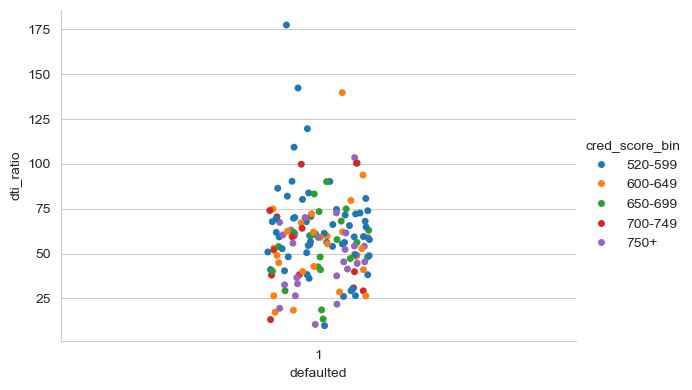

In [171]:
# credit score vs Default status
# Note -- used strip plot to jitter points and make them more visible
g = sns.catplot(#data = myData, #kind = 'scatter',
                myData.query('defaulted == 1'),
                kind = 'strip', 
                y = 'dti_ratio', x = 'defaulted', 
                height = 4, aspect = 1.5, 
                hue = 'cred_score_bin'
                #hue = 'interest_rate'
                #hue = 'age_bin'
                #hue = 'loan_status'
               )
                    
#for ax in g.axes.flat:
#    ax.set(title = 'DTI Ratio vs Default status', 
#ylabel = 'DTI ratio', xlabel = 'Default status')

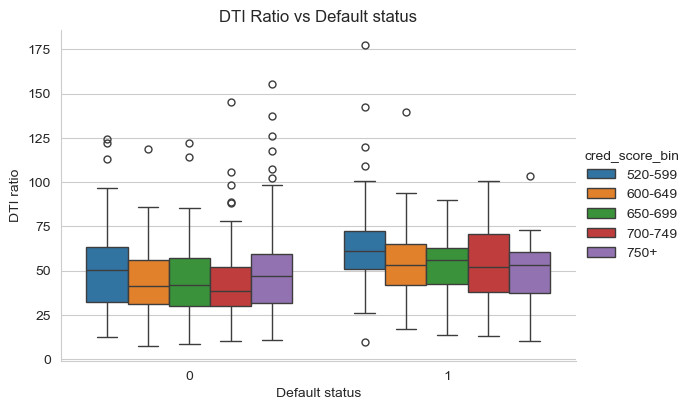

In [296]:
# DTI vs Default status
# Note -- used strip plot to jitter points and make them more visible
g = sns.catplot(data = myData, kind = 'box',
                #kind = 'strip', 
                x = 'defaulted', y = 'dti_ratio', 
                height = 4, aspect = 1.5, 
                hue = 'cred_score_bin'
                #hue = 'interest_rate'
                #hue = 'age_bin'
                #hue = 'education_level'
               )
                    
for ax in g.axes.flat:
    ax.set(title = 'DTI Ratio vs Default status', 
           ylabel = 'DTI ratio', xlabel = 'Default status')

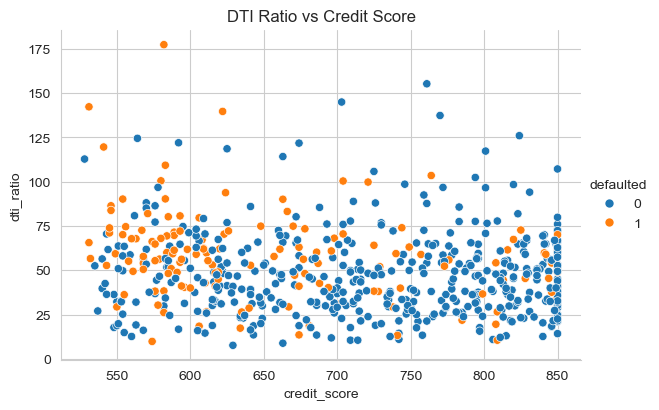

In [390]:
# Are there any trends between dti, credit score, and default?
sns.set_style('whitegrid')
   
g = sns.relplot(data = myData, kind = 'scatter',
                x = 'credit_score', y = 'dti_ratio', 
                height = 4, aspect = 1.5,
                hue = 'defaulted')

for ax in g.axes.flat:
    ax.set(title = 'DTI Ratio vs Credit Score')
# oranges are more common where higher DTI (50-75) and lower credit score (500-625) meet 

In [297]:
# get counts and loan amounts to assess prospective business lost based on DTI group cutoff
summary = myData.groupby(['dti_bin', 'defaulted'], observed = False).agg({'borrower_id':'count','loan_amount': 'sum'}).unstack()

summary.style.format({
    ('defaulted', True): '{:,}',
    ('defaulted', False): '{:,}',
    ('loan_amount', True): '${:,.0f}',
    ('loan_amount', False): '${:,.0f}'
})

In [88]:
# Drill into default rate by DTI bin & cred_score_bins
myData.pivot_table(index = 'cred_score_bin', columns = 'dti_bin', 
                   values = 'defaulted', aggfunc = 'mean', observed = False)*100


dti_bin,0-25%,26-35%,36-45%,46-50%,>51%
cred_score_bin,,,,,
520-599,10.000000,30.769231,38.461538,50.000000,60.273973
600-649,14.285714,21.428571,23.529412,27.272727,41.666667
650-699,20.000000,7.142857,27.272727,27.272727,38.709677
700-749,7.692308,10.526316,18.750000,0.000000,25.000000
750+,9.677419,7.142857,11.764706,13.043478,14.563107


In [391]:
# Drill into default rate by DTI bin & cred_score_bins
myData.pivot_table(index = 'cred_score_bin', columns = 'dti_bin', 
                   values = 'defaulted', aggfunc = ['mean', 'count'], observed = False)
# note that counts are small in several of these groups... 

mean                                         count         \
dti_bin            0-25%    26-35%    36-45%    46-50%      >51% 0-25% 26-35%   
cred_score_bin                                                                  
520-599         0.100000  0.307692  0.384615  0.500000  0.602740    10     13   
600-649         0.142857  0.214286  0.235294  0.272727  0.416667    14     14   
650-699         0.200000  0.071429  0.272727  0.272727  0.387097    10     14   
700-749         0.076923  0.105263  0.187500  0.000000  0.250000    13     19   
750+            0.096774  0.071429  0.117647  0.130435  0.145631    31     42   

                                   
dti_bin        36-45% 46-50% >51%  
cred_score_bin                     
520-599            13      6   73  
600-649            17     11   36  
650-699            11     11   31  
700-749            16      8   28  
750+               34     23  103

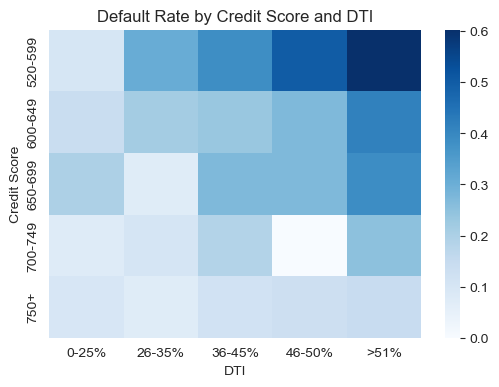

In [138]:
# heatmap showing default rate by DTI & Credit score intersections
fig, ax = plt.subplots(figsize = (6, 4))
ax = sns.heatmap(data = myData.pivot_table(index = 'cred_score_bin', columns = 'dti_bin', 
                   values = 'defaulted', aggfunc = 'mean', observed = False),
                cmap = 'Blues')
ax.set(title = 'Default Rate by Credit Score and DTI',
      xlabel = 'DTI',
      ylabel = 'Credit Score')

ax.get_figure().savefig('dti_credScore_heatmap.png')

In [313]:
myData['dti_bin'].drop_duplicates().tolist()

['>51%', '36-45%', '46-50%', '0-25%', '26-35%']

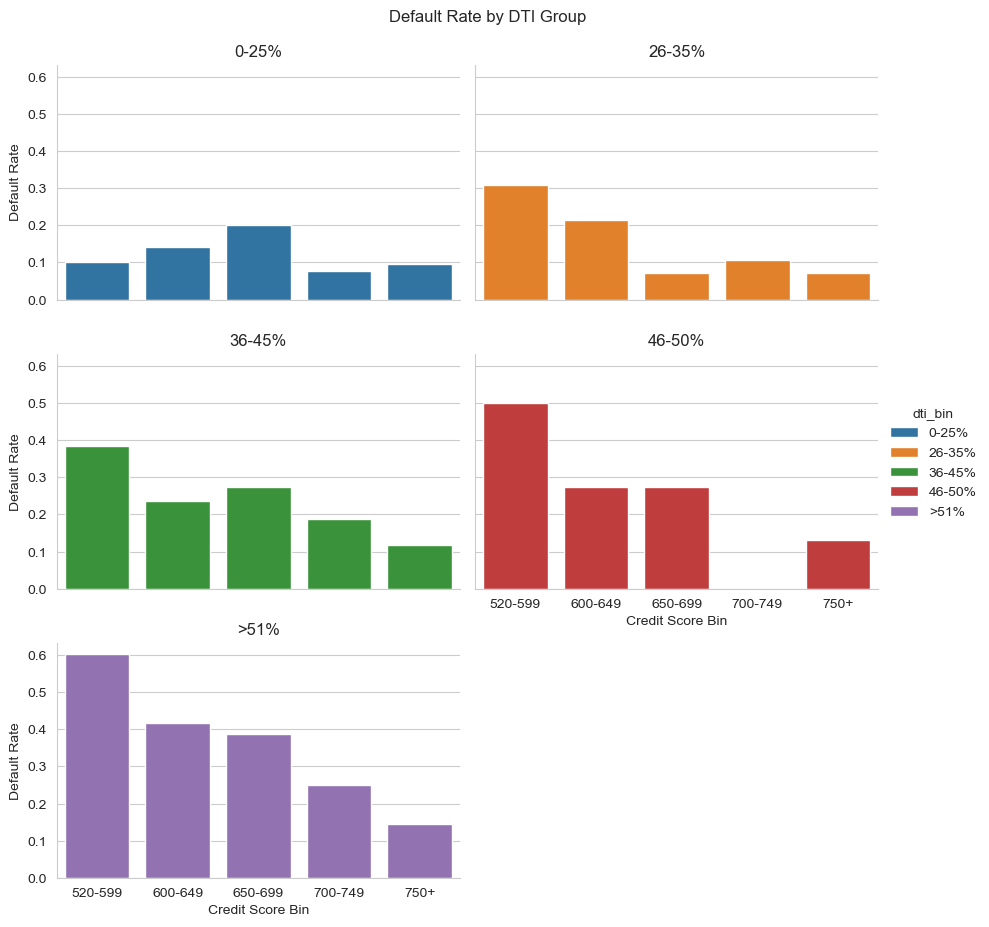

In [312]:
dti_order = ['0-25%', '26-35%', '36-45%', '46-50%', '>51%']
g = sns.catplot(data = myData.groupby(['cred_score_bin', 'dti_bin'], observed = False)[['defaulted']].mean(),
                kind = 'bar', x = 'cred_score_bin', y = 'defaulted', 
                col = 'dti_bin', col_wrap = 2, col_order = dti_order,
                hue = 'dti_bin', legend = True, height = 3, aspect = 1.5)
g.fig.suptitle('Default Rate by DTI Group', y = 1.025)

  
for ax, title in zip(g.axes.flat, dti_order):
    ax.set_title(title)
    ax.set_ylabel('Default Rate')
    ax.set_xlabel('Credit Score Bin')

### Assessment by Loan Status

In [ ]:
# skipped because loan status is after approval

### Assessment by Days Delinquent

In [ ]:
# skipped because days delinquent occurs after loan approval

### SAVE POINT

In [478]:
myData.to_pickle('finalPickle.pkl')

In [427]:
myData = pd.read_pickle('finalPickle.pkl')
myData.head()

,index,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,...,cred_score_bin,dti_bin,yrs_emp_bin,int_rate_bin,loan_number,loan_end_date,previous_loan_end_date,opened_before_previous_paid_off,debt_bins,less2yrs
0,0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,...,520-599,>51%,6-10 yrs,13%,1,2027-01-08,NaT,False,"[724.6, 1325.2)",0
1,0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,...,520-599,36-45%,6-10 yrs,14%,2,2028-08-13,2027-01-08,True,"[724.6, 1325.2)",0
2,1,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,...,520-599,>51%,2-5 yrs,12%,1,2028-06-28,NaT,False,"[724.6, 1325.2)",0
3,2,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,...,600-649,>51%,10+ yrs,11%,1,2029-05-18,NaT,False,"[1325.2, 1925.8)",0
4,3,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,...,700-749,36-45%,10+ yrs,9%,1,2028-03-24,NaT,False,"[724.6, 1325.2)",0


[Text(0.5, 1.0, 'Credit Score vs Defaulted')]

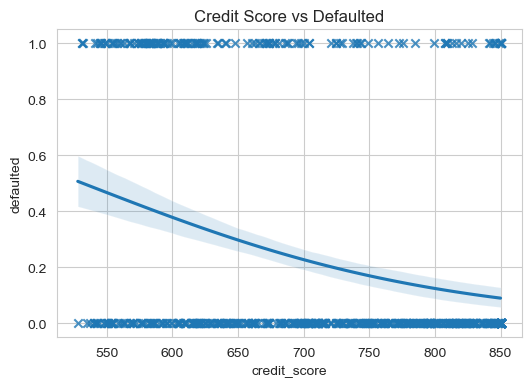

In [156]:
# Plot credit score vs default  and its regression line
fig, ax = plt.subplots(figsize = (6, 4))
ax = sns.regplot(data = myData, x = 'credit_score', y = 'defaulted', 
                 logistic = True, marker = "x")
ax.set(title = 'Credit Score vs Defaulted')

[Text(0.5, 1.0, 'DTI Ratio vs Defaulted')]

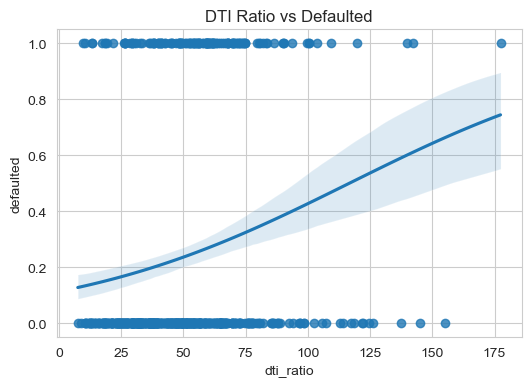

In [151]:
# Plot DTI ratio vs default  and its regression line
fig, ax = plt.subplots(figsize = (6, 4))
ax = sns.regplot(data = myData, x = 'dti_ratio', y = 'defaulted', logistic = True)
ax.set(title = 'DTI Ratio vs Defaulted')

[Text(0.5, 1.0, 'Loan Amount vs Defaulted')]

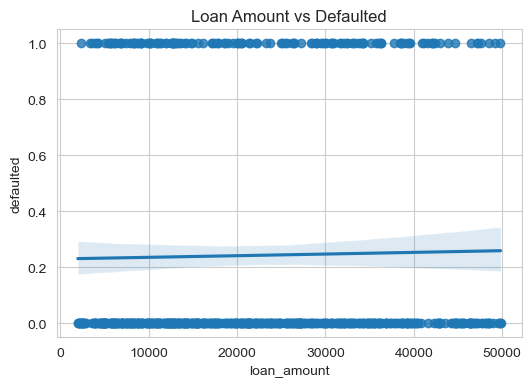

In [150]:
# Plot loan amount vs default  and its regression line
fig, ax = plt.subplots(figsize = (6, 4))
ax = sns.regplot(data = myData, x = 'loan_amount', y = 'defaulted', logistic = True)
ax.set(title = 'Loan Amount vs Defaulted') 

[Text(0.5, 1.0, 'Interest Rate vs Defaulted')]

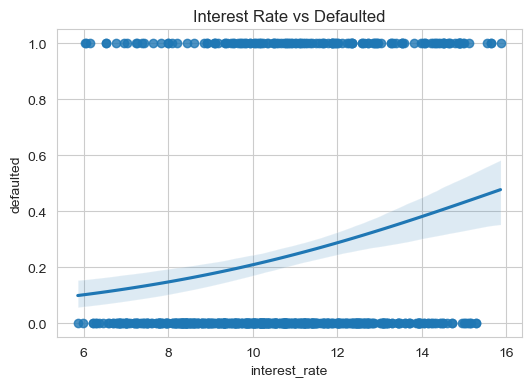

In [149]:
# Plot interest rate vs default and its regression line
fig, ax = plt.subplots(figsize = (6, 4))
ax = sns.regplot(data = myData, x = 'interest_rate', y = 'defaulted', logistic = True)
ax.set(title = 'Interest Rate vs Defaulted')

[Text(0.5, 1.0, 'Age vs Defaulted')]

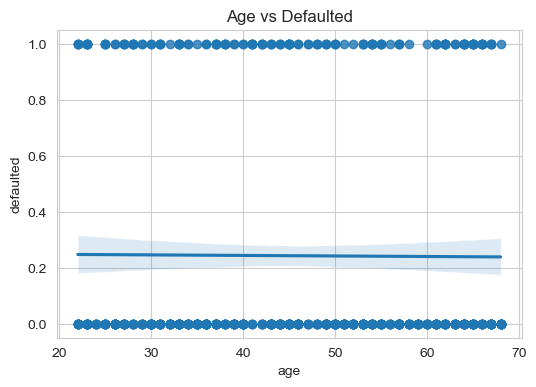

In [148]:
# Plot age vs default and its regression line
fig, ax = plt.subplots(figsize = (6, 4))
ax = sns.regplot(data = myData, x = 'age', y = 'defaulted', logistic = True)
ax.set(title = 'Age vs Defaulted')

[Text(0.5, 1.0, 'Years Employed vs Defaulted')]

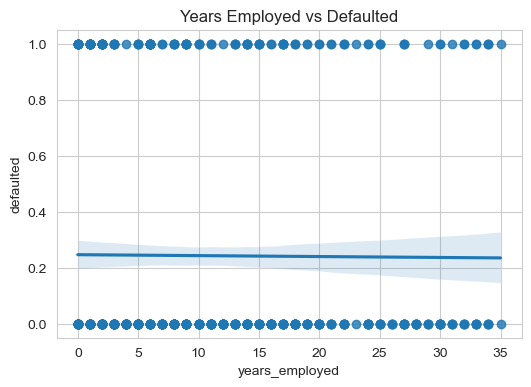

In [147]:
# PLot years employed vs default and its regression line
fig, ax = plt.subplots(figsize = (6, 4))
ax = sns.regplot(data = myData, x = 'years_employed', y = 'defaulted', logistic = True)
ax.set(title = 'Years Employed vs Defaulted')

[Text(0.5, 1.0, 'Annual Income vs Defaulted')]

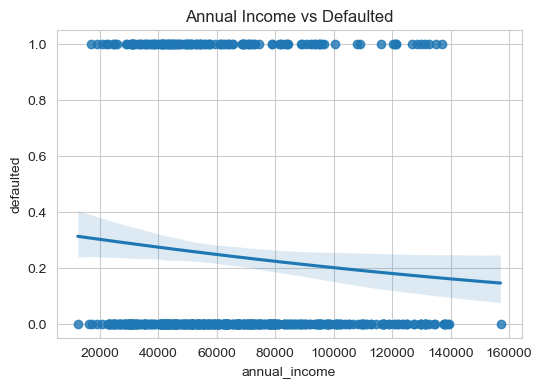

In [146]:
# Plot annual income vs default  and its regression line
fig, ax = plt.subplots(figsize = (6, 4))
ax = sns.regplot(data = myData, x = 'annual_income', y = 'defaulted', logistic = True)
ax.set(title = 'Annual Income vs Defaulted')

[Text(0.5, 1.0, 'Existing Monthly Debt vs Defaulted')]

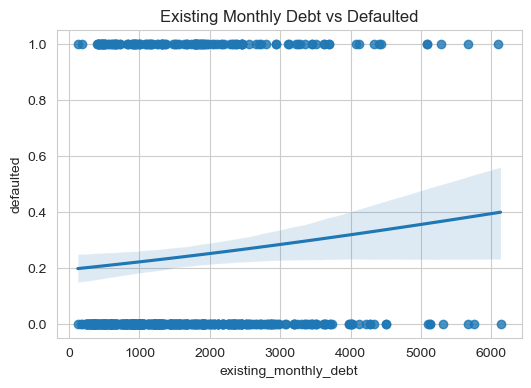

In [145]:
# PLot existing monthly debt vs default  and its regression line
fig, ax = plt.subplots(figsize = (6, 4))
ax = sns.regplot(data = myData, x = 'existing_monthly_debt', y = 'defaulted', logistic = True)
ax.set(title = 'Existing Monthly Debt vs Defaulted')

[Text(0.5, 1.0, 'Monthly Payment vs Defaulted')]

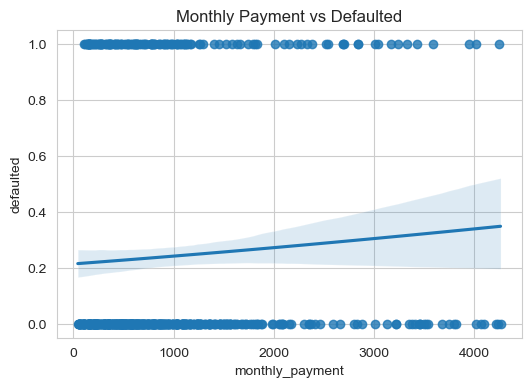

In [144]:
# plot monthly payment vs default  and its regression line
fig, ax = plt.subplots(figsize = (6, 4))
ax = sns.regplot(data = myData, x = 'monthly_payment', y = 'defaulted', logistic = True)
ax.set(title = 'Monthly Payment vs Defaulted')

In [428]:
myData.columns
#myData.head(1)

Index(['index', 'borrower_id', 'age', 'state', 'education_level',
       'employment_status', 'years_employed', 'annual_income', 'credit_score',
       'home_ownership', 'dependents', 'existing_monthly_debt', 'age_bin',
       'loan_id', 'application_date', 'loan_purpose', 'loan_amount',
       'term_months', 'interest_rate', 'monthly_payment', 'dti_ratio',
       'loan_status', 'days_delinquent', 'defaulted', 'cred_score_bin',
       'dti_bin', 'yrs_emp_bin', 'int_rate_bin', 'loan_number',
       'loan_end_date', 'previous_loan_end_date',
       'opened_before_previous_paid_off', 'debt_bins', 'less2yrs'],
      dtype='object')

In [430]:
# create list of numeric columns to test
numColumns = ['defaulted', 'credit_score',  'dti_ratio', 'loan_amount', 'interest_rate',
              'age', 'years_employed', 'annual_income', 'existing_monthly_debt', 'monthly_payment']

In [431]:
myDataNum = myData[numColumns]
myDataNum.corr(method = 'pearson')[['defaulted']].sort_values(by = 'defaulted', ascending = False) # Pearson Correlation (vs Kendall or spearman)

,defaulted
defaulted,1.000000
interest_rate,0.198930
dti_ratio,0.192454
existing_monthly_debt,0.083325
monthly_payment,0.061867
loan_amount,0.018116
age,-0.006085
years_employed,-0.007199
annual_income,-0.081546
credit_score,-0.286394


<Axes: >

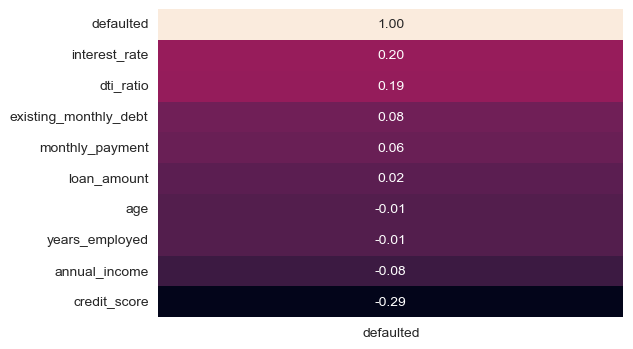

In [432]:
# create heatmap specific to correlation with defaulted
sns.heatmap(data = myDataNum.corr(method = 'pearson')[['defaulted']].sort_values(by = 'defaulted', ascending = False), 
            #cmap = 'Blues', 
            annot = True, cbar = False, fmt = f'.2f')

### Assess correlation on all columns

In [122]:
# move Defaulted column to first column in dataframe
myData = myData.set_index('defaulted').reset_index()

In [442]:
# create copy of data set with all numeric values (converts objects to category codes)
df_numerized = myData.copy()
df_numerized = df_numerized.drop(columns = ['index', 'borrower_id', 'loan_id', 
                                            'application_date', 'cred_score_bin', 
                                            'dti_bin', 'yrs_emp_bin',
                                            'int_rate_bin', 'loan_end_date', 'previous_loan_end_date',
                                            'debt_bins', 'less2yrs'])
                                           
for col_name in df_numerized.columns:
    if(df_numerized[col_name].dtype == 'object'):
        df_numerized[col_name] = df_numerized[col_name].astype ('category')
        df_numerized[col_name] = df_numerized[col_name].cat.codes

df_numerized.head()

,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt,...,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted,loan_number,opened_before_previous_paid_off
0,62,4,3,4,6,31020,596,2,1,892,...,16100.0,36,13.05,542.86,55.5,3,0,0,1,False
1,62,4,3,4,6,31020,596,2,1,892,...,5600.0,48,14.21,153.62,40.4,1,138,1,2,True
2,24,3,3,1,4,40188,543,1,2,869,...,44700.0,36,12.37,1492.59,70.5,3,0,0,1,False
3,50,16,1,0,22,41014,611,0,0,1806,...,9200.0,48,11.18,238.58,59.8,1,34,1,1,False
4,43,25,3,1,19,35036,701,0,2,928,...,11200.0,36,9.66,359.61,44.1,0,0,0,1,False


In [443]:
df_numerized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              601 non-null    int64  
 1   state                            601 non-null    int8   
 2   education_level                  601 non-null    int8   
 3   employment_status                601 non-null    int8   
 4   years_employed                   601 non-null    int64  
 5   annual_income                    601 non-null    int64  
 6   credit_score                     601 non-null    int64  
 7   home_ownership                   601 non-null    int8   
 8   dependents                       601 non-null    int64  
 9   existing_monthly_debt            601 non-null    int64  
 10  age_bin                          601 non-null    int8   
 11  loan_purpose                     601 non-null    int8   
 12  loan_amount           

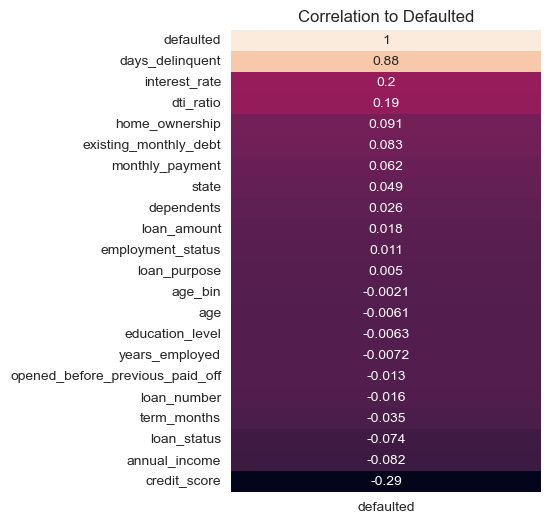

In [444]:
# create heatmap of correlation to defaulted
correlation_defaulted = df_numerized.corr(method = 'pearson')[['defaulted']] \
    .sort_values('defaulted', ascending = False)

fig, ax = plt.subplots(figsize = (4, 6))

ax = sns.heatmap(correlation_defaulted, annot = True, cbar = False)
plt.title('Correlation to Defaulted', loc = 'center')
plt.show()

fig.subplots_adjust(left = 0.5)

ax.get_figure().savefig('corr_all_features.png')

### Extra from here

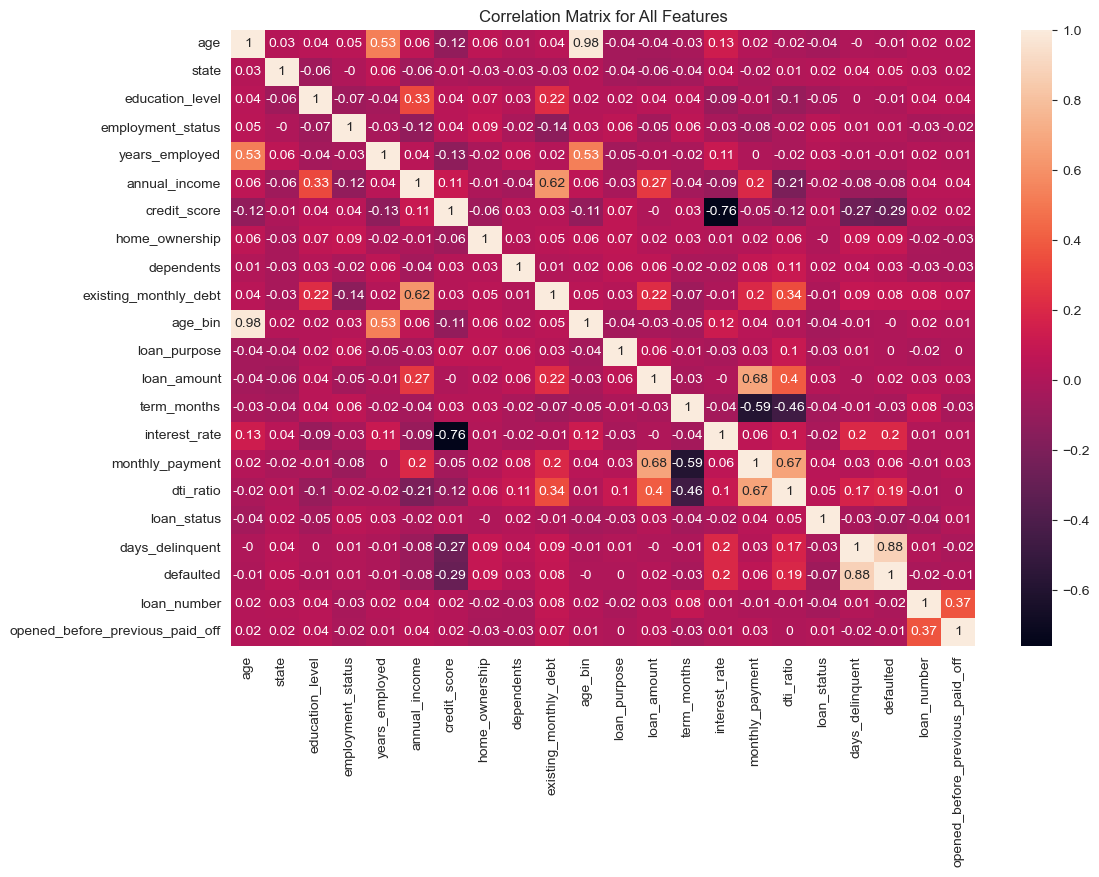

In [445]:
correlation_matrix = df_numerized.corr().round(2)

matplotlib.rcParams['figure.figsize'] = (12,8) # adjusts the config of the plots 

sns.heatmap(correlation_matrix, annot = True)
plt.title('Correlation Matrix for All Features')
plt.show()

In [451]:
# view correlation pairs by sets
corr_pairs = correlation_matrix.unstack()
corr_pairs

age                              age                                1.00
                                 state                              0.03
                                 education_level                    0.04
                                 employment_status                  0.05
                                 years_employed                     0.53
                                                                    ... 
opened_before_previous_paid_off  loan_status                        0.01
                                 days_delinquent                   -0.02
                                 defaulted                         -0.01
                                 loan_number                        0.37
                                 opened_before_previous_paid_off    1.00
Length: 484, dtype: float64

In [454]:
# Sort correlation pairs by value
pd.set_option('display.max_rows', None)
sorted_pairs = corr_pairs.sort_values()
sorted_pairs

interest_rate                    credit_score                      -0.76
credit_score                     interest_rate                     -0.76
term_months                      monthly_payment                   -0.59
monthly_payment                  term_months                       -0.59
term_months                      dti_ratio                         -0.46
dti_ratio                        term_months                       -0.46
defaulted                        credit_score                      -0.29
credit_score                     defaulted                         -0.29
                                 days_delinquent                   -0.27
days_delinquent                  credit_score                      -0.27
dti_ratio                        annual_income                     -0.21
annual_income                    dti_ratio                         -0.21
existing_monthly_debt            employment_status                 -0.14
employment_status                existing_monthly_d

In [453]:
# restrict correlation to pairs greater than 0.5
pd.set_option('display.max_rows', None)
high_corr = sorted_pairs[(sorted_pairs) > 0.5]
high_corr

age_bin                          years_employed                     0.53
age                              years_employed                     0.53
years_employed                   age_bin                            0.53
                                 age                                0.53
existing_monthly_debt            annual_income                      0.62
annual_income                    existing_monthly_debt              0.62
monthly_payment                  dti_ratio                          0.67
dti_ratio                        monthly_payment                    0.67
monthly_payment                  loan_amount                        0.68
loan_amount                      monthly_payment                    0.68
days_delinquent                  defaulted                          0.88
defaulted                        days_delinquent                    0.88
age_bin                          age                                0.98
age                              age_bin           

In [306]:
# save points for DFs used in correlation analysis
myDataNum.to_pickle('basicNumDF.pkl')
df_numerized.to_pickle('numerizedDF.pkl')


In [494]:
myData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 35 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   index                            601 non-null    int64         
 1   borrower_id                      601 non-null    object        
 2   age                              601 non-null    int64         
 3   state                            601 non-null    object        
 4   education_level                  601 non-null    object        
 5   employment_status                601 non-null    object        
 6   years_employed                   601 non-null    int64         
 7   annual_income                    601 non-null    int64         
 8   credit_score                     601 non-null    int64         
 9   home_ownership                   601 non-null    object        
 10  dependents                       601 non-null    int64        

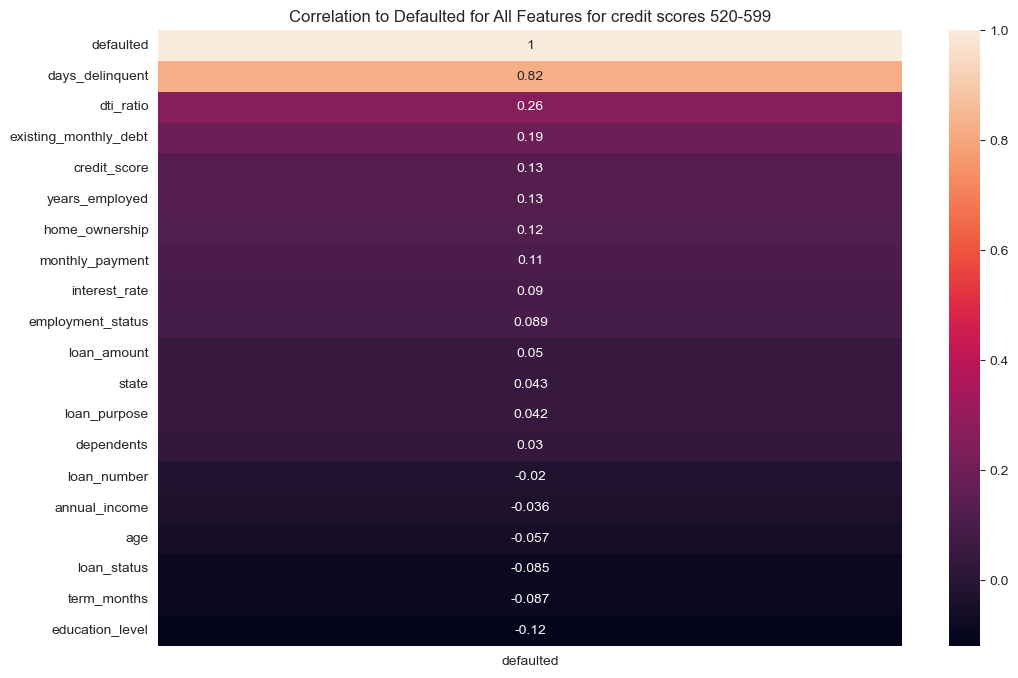

In [497]:
# correlation between dti and interest rate per credit score bin

# create copy of data set with all numeric values (converts objects to category codes)
df_numerized_1 = myData.query('cred_score_bin == "520-599"').copy()
df_numerized_1 = df_numerized_1.drop(columns = ['borrower_id', 'loan_id', 'application_date', 
                                                'cred_score_bin', 'dti_bin', 'yrs_emp_bin', 
                                                'int_rate_bin', 'age_bin', 'debt_bins', 
                                                'loan_end_date', 'previous_loan_end_date',
                                                'opened_before_previous_paid_off', 'less2yrs', 
                                                'loan_amt_bin', 'index'])
for col_name in df_numerized_1.columns:
    if(df_numerized_1[col_name].dtype == 'object'):
        df_numerized_1[col_name] = df_numerized_1[col_name].astype ('category')
        df_numerized_1[col_name] = df_numerized_1[col_name].cat.codes

#df_numerized.head()

correlation_defaulted = df_numerized_1.corr(method = 'pearson')[['defaulted']].sort_values('defaulted', ascending = False)
sns.heatmap(correlation_defaulted, annot = True)
plt.title('Correlation to Defaulted for All Features for credit scores 520-599')
plt.show()

[Text(0.5, 1.0, 'Avg default Credit Score, DTI vs Interest Rate'),
 Text(0.5, 60.7222222222222, 'Interest Rate'),
 Text(122.72222222222221, 0.5, 'Credit Score + DTI group')]

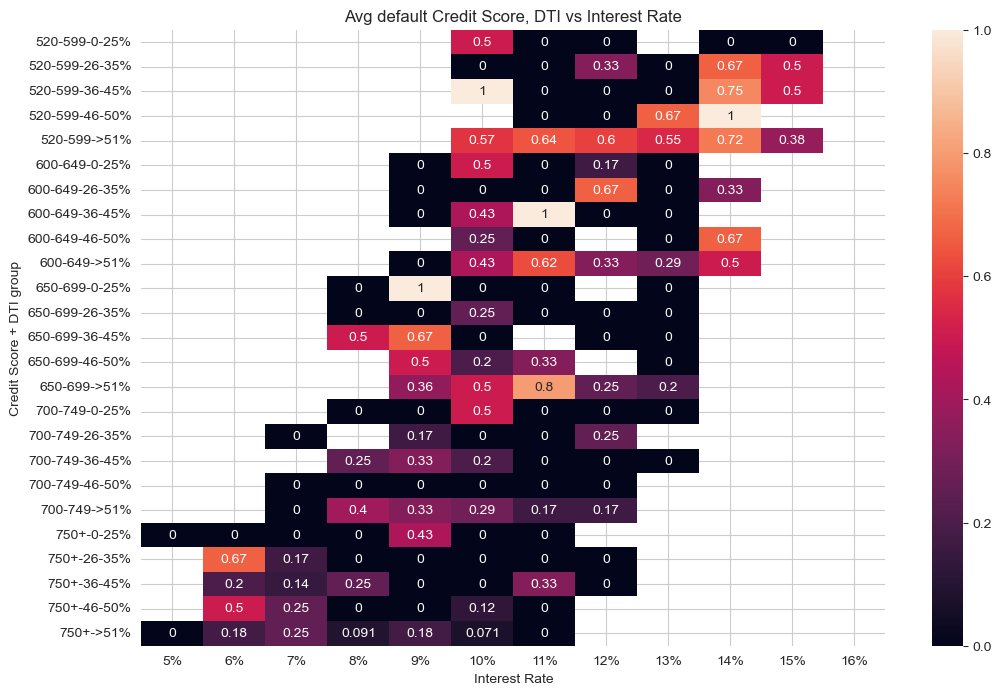

In [501]:
# What does the mean default rate the top correlation factors look like?
myTable = myData.groupby(['cred_score_bin', 'dti_bin', 'int_rate_bin'], observed = False)['defaulted'].mean().unstack().round(3)
ax = sns.heatmap(data = myTable, annot = True)
ax.set(title = 'Avg default Credit Score, DTI vs Interest Rate', 
      xlabel = 'Interest Rate', ylabel = 'Credit Score + DTI group')

[Text(0.5, 1.0, 'Count of defaultors by Credit Score, DTI vs Interest Rate groups'),
 Text(0.5, 60.7222222222222, 'Interest Rate'),
 Text(122.72222222222221, 0.5, 'Credit Score + DTI group')]

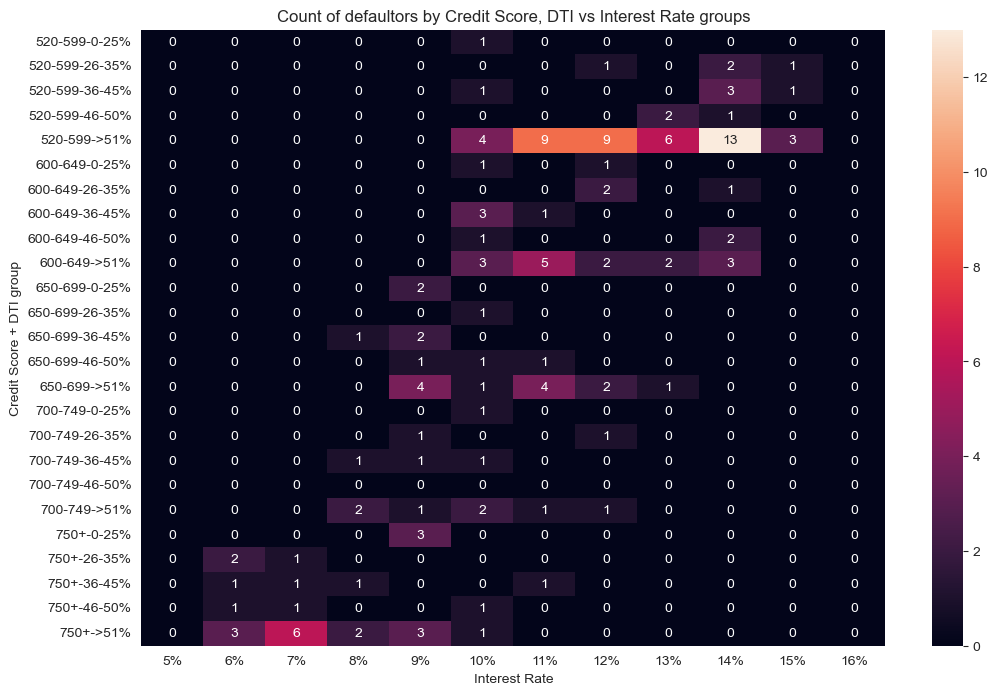

In [509]:
# how many default observations in each category?
#countsTable = myData.groupby(['cred_score_bin', 'dti_bin', 'int_rate_bin'], observed = False)['defaulted'].sum().unstack().round(3)
countsTable = myData.pivot_table(index = ['cred_score_bin', 'dti_bin'], columns = 'int_rate_bin', values = 'defaulted', aggfunc = 'sum', observed = False).round(3)
ax = sns.heatmap(data = countsTable, annot = True)
ax.set(title = 'Count of defaultors by Credit Score, DTI vs Interest Rate groups', 
      xlabel = 'Interest Rate', ylabel = 'Credit Score + DTI group')

[Text(0.5, 1.0, 'Count of Loans by Credit Score, DTI vs Interest Rate groups'),
 Text(0.5, 60.7222222222222, 'Interest Rate'),
 Text(122.72222222222221, 0.5, 'Credit Score + DTI group')]

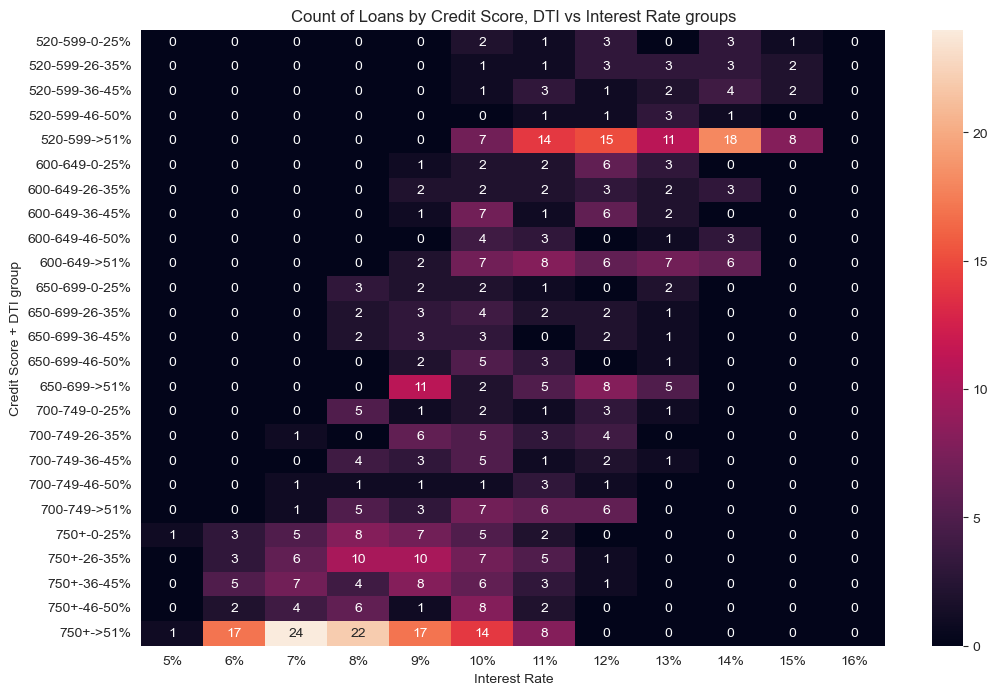

In [511]:
# how many total loans in each category?
totalCountsTable = myData.pivot_table(index = ['cred_score_bin', 'dti_bin'], columns = 'int_rate_bin', values = 'defaulted', aggfunc = 'count', observed = False).round(3)
ax = sns.heatmap(data = totalCountsTable, annot = True)
ax.set(title = 'Count of Loans by Credit Score, DTI vs Interest Rate groups', 
      xlabel = 'Interest Rate', ylabel = 'Credit Score + DTI group')

# pick cutoffs for each category and then run avg default rate for combinations to show results

In [547]:
# 
print('Mean Default Rate (%) if Credit > 600, DTI < 40, Int < 10')
print('within -> ', round((myData.query('credit_score >= 600 and dti_ratio <= 40 and interest_rate <= 10')['defaulted'].mean()) * 100, 2))
print('outside -> ', round((myData.query('credit_score < 600 and dti_ratio > 40 and interest_rate > 10')['defaulted'].mean()) * 100, 2))

Mean Default Rate (%) if Credit > 600, DTI < 40, Int < 10
within ->  11.54
outside ->  57.65


In [552]:
# 
print('Mean Default Rate (%) if Credit > 650, DTI < 30, Int < 11')
print('within -> ', round((myData.query('credit_score >= 650 and dti_ratio <= 30 and interest_rate <= 11')['defaulted'].mean()) * 100, 2))
print('outside -> ', round((myData.query('credit_score < 650 and dti_ratio > 30 and interest_rate > 11')['defaulted'].mean()) * 100, 2))
# this goes higher (within) because the # of loans is reduced and the number of defaults for this portion is higher historically

Mean Default Rate (%) if Credit > 650, DTI < 30, Int < 11
within ->  11.27
outside ->  45.65


In [563]:
# 
print('Mean Default Rate (%) if Credit > 650, DTI < 45, Int < 10')
print('within -> ', round((myData.query('credit_score >= 650 and dti_ratio <= 45 and interest_rate <= 10')['defaulted'].mean()) * 100, 2))
print('outside -> ', round((myData.query('credit_score < 650 and dti_ratio > 45 and interest_rate > 10')['defaulted'].mean()) * 100, 2))
# this goes higher (within) because the # of loans is reduced and the number of defaults for this portion is higher historically

Mean Default Rate (%) if Credit > 650, DTI < 45, Int < 10
within ->  15.32
outside ->  52.42


In [564]:
# Credit score <= 650 and DTI <= 45, no restriction on interest rate (which is assigned to a loan based on borrower's credit rating, DTI, etc)
print('Mean Default Rate (%) if Credit > 650, DTI < 45')
print('within -> ', round((myData.query('credit_score >= 650 and dti_ratio <= 45')['defaulted'].mean()) * 100, 2))
print('outside -> ', round((myData.query('credit_score < 650 and dti_ratio > 45')['defaulted'].mean()) * 100, 2))


Mean Default Rate (%) if Credit > 650, DTI < 45
within ->  11.7
outside ->  51.59


In [562]:
# Credit score <= 600 and DTI <= 40, no restriction on interest rate (which is assigned to a loan based on borrower's credit rating, DTI, etc)
print('Mean Default Rate (%) if Credit > 650, DTI < 40')
print('within -> ', round((myData.query('credit_score >= 600 and dti_ratio <= 40')['defaulted'].mean()) * 100, 2))
print('outside -> ', round((myData.query('credit_score < 600 and dti_ratio > 40')['defaulted'].mean()) * 100, 2))


Mean Default Rate (%) if Credit > 650, DTI < 40
within ->  11.17
outside ->  57.65


In [97]:
# Credit score <= 700 and DTI <= 35, interest rate < 14%
print('Mean Default Rate (%) if Credit > 750, DTI < 35, Int < 14')
print('within -> ', round((myData.query('credit_score >= 700 and dti_ratio <= 35 and interest_rate < 14')['defaulted'].mean()) * 100, 2))
print('outside -> ', round((myData.query('credit_score < 700 and dti_ratio > 35 and interest_rate >= 14')['defaulted'].mean()) * 100, 2))
# TBD

Mean Default Rate (%) if Credit > 750, DTI < 35, Int < 14
within ->  8.57
outside ->  61.9


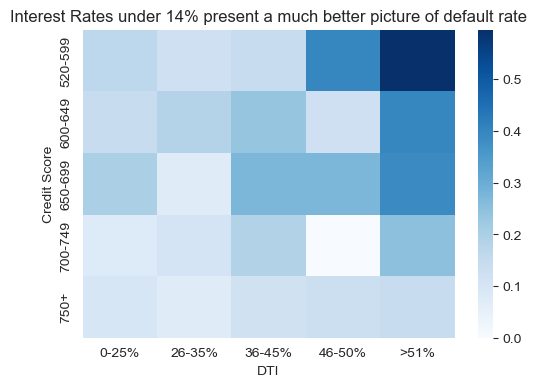

In [137]:
# heatmap showing default rate by DTI & Credit score intersections when interest rates under 14% are used
fig, ax = plt.subplots(figsize = (6, 4))
ax = sns.heatmap(data = myData.query('interest_rate < 14')\
    .pivot_table(index = 'cred_score_bin', columns = 'dti_bin', 
                   values = 'defaulted', aggfunc = 'mean', observed = False),
                cmap = 'Blues')
ax.set(title = 'Interest Rates under 14% present a much better picture of default rate',
      xlabel = 'DTI',
      ylabel = 'Credit Score')

ax.get_figure().savefig('dti_credScore_under14Int_heatmap.png')

# Regression analysis

In [565]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [566]:
# Define X and y
X = myData[['credit_score', 'dti_ratio', 'interest_rate']]
y = myData['defaulted']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.40, random_state=13)

# Create Pipeline
logReg = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000))])

# Fit the model
logReg.fit(X_train, y_train)

# Score the model
train_score = logReg.score(X_train, y_train)
test_score = logReg.score(X_test, y_test)

print(f"Training Accuracy: {train_score:.3f}")
print(f"Testing Accuracy : {test_score:.3f}")

Training Accuracy: 0.786
Testing Accuracy : 0.747


In [570]:
# Make predictions
y_pred = logReg.predict(X_test)
y_prob = logReg.predict_proba(X_test)[:, 1]

# Create results DataFrame
results = X_test.copy()

results['actual_default'] = y_test
results['predicted_default'] = y_pred
results['predicted_probability'] = y_prob

# Residuals
results['residual'] = (results['actual_default'] - results['predicted_probability'])
results['class_residual'] = (results['actual_default'] - results['predicted_default'])

#print(results.head())
results.to_excel('Logistic Results.xlsx')

In [575]:
coef = pd.DataFrame({ 'Feature' : X.columns,
                      'Coefficient': logReg.named_steps['model'].coef_[0] })

coef = coef.sort_values('Coefficient', key = abs, ascending = False)
print(coef)

         Feature  Coefficient
0   credit_score    -0.688103
1      dti_ratio     0.309715
2  interest_rate     0.047688


In [577]:
import numpy as np
odds_ratios = pd.DataFrame({'Feature': X.columns, 
                            'Coefficient' : logReg.named_steps['model'].coef_[0],
                            'Odd Ratio': np.exp(logReg.named_steps['model'].coef_[0]) })
print(odds_ratios)

         Feature  Coefficient  Odd Ratio
0   credit_score    -0.688103   0.502528
1      dti_ratio     0.309715   1.363036
2  interest_rate     0.047688   1.048843


In [ ]:
## -- OPTION 2 -- 

In [579]:
import statsmodels.formula.api as smf
from statsmodels.api import families
from sklearn.model_selection import train_test_split

In [581]:
# Split data into train and test
train, test = train_test_split(myData, test_size=0.40, random_state=13)

# create logistic model
LogModel = smf.glm(formula = 'defaulted ~ credit_score + dti_ratio + interest_rate', family = families.Binomial(), data = train).fit()
print(LogModel.summary2())

               Results: Generalized linear model
Model:              GLM              AIC:            350.2453  
Link Function:      Logit            BIC:            -1753.2077
Dependent Variable: defaulted        Log-Likelihood: -171.12   
Date:               2026-07-15 15:32 LL-Null:        -190.69   
No. Observations:   360              Deviance:       342.25    
Df Model:           3                Pearson chi2:   366.      
Df Residuals:       356              Scale:          1.0000    
Method:             IRLS                                       
---------------------------------------------------------------
                 Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
---------------------------------------------------------------
Intercept        2.9366   2.2742  1.2913 0.1966 -1.5207  7.3940
credit_score    -0.0073   0.0021 -3.4073 0.0007 -0.0115 -0.0031
dti_ratio        0.0129   0.0052  2.4845 0.0130  0.0027  0.0231
interest_rate    0.0123   0.0897  0.1376 0.8906 -0.1634

In [582]:
LogModel.predict(test)

553    0.204988
222    0.097988
477    0.185641
289    0.117405
135    0.222043
44     0.251797
150    0.179292
261    0.225397
39     0.299699
376    0.221227
588    0.113591
513    0.054545
157    0.474620
125    0.309063
580    0.059219
529    0.404068
591    0.127381
523    0.309183
93     0.085263
29     0.145756
144    0.165709
416    0.097171
353    0.098258
577    0.105572
346    0.140345
399    0.256246
589    0.068381
69     0.157669
235    0.104834
304    0.271611
590    0.414603
147    0.120677
187    0.282793
485    0.402309
519    0.170529
177    0.152431
136    0.465682
551    0.294800
161    0.362752
352    0.101489
0      0.371054
347    0.313925
294    0.440628
286    0.196064
234    0.125540
307    0.348527
3      0.353315
99     0.232356
183    0.088384
320    0.083428
581    0.062934
556    0.158136
482    0.505223
249    0.216790
465    0.459341
65     0.158543
98     0.251801
547    0.318473
491    0.281605
33     0.449077
241    0.498271
406    0.228639
151    0

In [586]:
# How often does model predict outcome of training data?
np.mean(train['defaulted'] == np.round(LogModel.predict()))

np.float64(0.775)

# write a summary of top 3 risk factors and suggest specific thresholds (min cred score or max DTI) for the underwriting team